# 05 SPCX Extension: Raw Data → Simulated Tape → Hedging Engine → Evaluation

This notebook extends the intraday delta-hedging study from ES options to **SPCX**, a
Nasdaq-listed equity with OPRA-listed options. It is a single self-contained pipeline that
reproduces, for SPCX, the outputs of the whole ES stack:

| ES pipeline stage | ES artifact | SPCX artifact (this notebook) |
| --- | --- | --- |
| `01_trade_flow_simulator.py` -- synthetic executed-trade tape | `data/simulated/simulated_executed_trades.csv` | `data/simulated/simulated_executed_trades_spcx.csv` |
| market-inputs panel (5-minute bars + vol + rate) | `data/processed/market_inputs_2026.csv` | `data/processed/market_inputs_spcx_2026.csv` |
| `02_baseline_strategies.ipynb` -- signed delta arrivals | `data/processed/executed_trade_delta_arrivals.csv` | `data/processed/executed_trade_delta_arrivals_spcx.csv` |
| `04_alex_implementation.ipynb` -- revalued book delta, benchmarks, grid, hedge log | `alex_book_delta_paths.csv`, `alex_benchmark_results.csv`, `alex_grid_results.csv`, `alex_hedge_events.csv` | `spcx_book_delta_paths.csv`, `spcx_benchmark_results.csv`, `spcx_grid_results.csv`, `spcx_hedge_events.csv` |
| `03_strategy_comparison.ipynb` -- theta*, frontier, sensitivities, blotter, recommendation | figures + `alex_theta_star_*.csv` | `spcx_*` figures + `spcx_theta_star_*.csv` |

(Notebook 02's superseded whole-contract baseline engine is deliberately **not** re-run --
notebook 03's header note retired it in favor of the Eq. 17-19 revaluation engine; its
surviving artifact, the delta-arrival tape, is reproduced here.)

**Raw inputs** (added under `data/raw/`):

- `opra-pillar-YYYYMMDD.tcbbo.csv` -- every SPCX option trade with the consolidated BBO at
  trade time (OPRA TCBBO schema, OCC symbology, e.g. `SPCX  260717C00265000`). The first
  session (2026-06-16) lists only standard monthlies (the odd-looking `260618` / `270617`
  dates are 3rd Fridays shifted for the Juneteenth closure); weekly expiries (`260626`,
  `260724`, ...) join the tape from 2026-06-17 onward. Unlike the ES simulator -- whose
  monthly-only scope is a deliberate design choice tied to its futures symbology -- the
  SPCX pipeline keeps **every OPRA-listed expiry**, since the raw data covers the full
  listed book and weeklies carry a large share of the near-dated flow.
- `xnas-itch-YYYYMMDD.bbo-1s.csv` -- SPCX underlying: last trade + best bid/offer sampled
  every second (Nasdaq ITCH BBO-1s). Seconds with no new print repeat the previous trade,
  so trade-level aggregates dedupe on a fresh `ts_event`.

**What changes vs. the ES notebooks (futures option → equity option):**

1. **Units (Eq. 11).** One SPCX option delivers **100 shares**, and the hedge instrument is
   the stock itself ($1 of P&L per share per $1 move). The ES multiplier-cancellation
   argument does not apply here: an option trade's book-delta contribution is
   `s_i * n_i * delta_i * 100` **shares**, and dollar P&L is simply shares x price move
   (no further multiplier anywhere).
2. **Pricing.** Black-Scholes spot delta (SOFR rate, zero dividend yield) replaces the
   Black-76 futures delta.
3. **Volatility input.** The Bloomberg 1M BVOL file ends 2026-05-29, before the SPCX
   window (Jun 16 - Jul 17), and SPX vol would be the wrong underlying anyway. The panel's
   `bvol_1m` is instead a daily **ATM implied vol backed out of the OPRA tape itself**
   (near-1-month expiry, near-the-money trades, mid-quote premium inverted per trade,
   daily median).
4. **Rate input.** The SOFR OIS file also ends 2026-05-29; the last 1M fix is carried
   forward flat (rates move slowly at this horizon; the delta is insensitive to it).
5. **Session.** Equity RTH 09:30-16:00 ET (the ES notebooks use the 16:15 futures close).
6. **Cost model calibration.** The half-spread is *measured* from the underlying's real
   BBO (the ES notebooks had to proxy it with one tick); the impact coefficient `alpha` is
   re-anchored to a 100-share clip at this panel's median ADV; the closing-auction impact
   factor is re-derived from this panel's own last-bar volume concentration.

**Known caveat:** the BBO-1s file keeps only the last print per second, so the share-volume
proxy (bars, ADV) undercounts true volume; the synthetic option tape also trades far more
underlying-equivalent volume than the stock's printed ADV. Cost *levels* therefore inherit
the cost-model assumptions even more than in ES -- the normalized comparisons and the
Section 12 sensitivity sweeps are the robust quantities, exactly as in notebook 03.

## 1. Setup

In [1]:
from pathlib import Path
import itertools
import math
import re
import time
from datetime import datetime
from zoneinfo import ZoneInfo

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import brentq
from scipy.stats import norm

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
SIM_DIR = DATA_DIR / 'simulated'
PROCESSED_DIR = DATA_DIR / 'processed'
OUTPUT_TABLE_DIR = PROJECT_ROOT / 'outputs' / 'tables'
OUTPUT_FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'figures'
for _d in (SIM_DIR, PROCESSED_DIR, OUTPUT_TABLE_DIR, OUTPUT_FIGURE_DIR):
    _d.mkdir(parents=True, exist_ok=True)

# --- instrument constants ---------------------------------------------------
# SPCX is a Nasdaq-listed equity: one option contract delivers 100 shares and the hedge
# instrument is the stock itself ($1 of P&L per share per $1 move). Book delta is
# therefore measured in SHARES: option deltas convert to the hedge unit through the
# 100-share contract multiplier, and dollar P&L needs no further scaling.
OPT_MULT = 100.0
BAR_MINUTES = 5
RTH_OPEN_ET = '09:30'
RTH_CLOSE_ET = '16:00'          # equity session close (ES notebooks use 16:15)
ET = ZoneInfo('America/New_York')
RTH_OPEN_T = pd.Timestamp(RTH_OPEN_ET).time()
RTH_CLOSE_T = pd.Timestamp(RTH_CLOSE_ET).time()

# --- trade-flow simulator design parameters (same as 01_trade_flow_simulator.py) ---
MM_FRACTION = 0.30      # fraction of real daily option volume we assume we market-make
TIME_JITTER_SEC = 120   # +/- jitter on bootstrapped trade times
SEED = 42

# --- artifact paths ---------------------------------------------------------
MARKET_INPUTS_PATH = PROCESSED_DIR / 'market_inputs_spcx_2026.csv'
EXECUTED_TRADES_PATH = SIM_DIR / 'simulated_executed_trades_spcx.csv'
DELTA_ARRIVALS_PATH = PROCESSED_DIR / 'executed_trade_delta_arrivals_spcx.csv'
BOOK_DELTA_PATHS_PATH = PROCESSED_DIR / 'spcx_book_delta_paths.csv'
BENCHMARKS_PATH = OUTPUT_TABLE_DIR / 'spcx_benchmark_results.csv'
GRID_RESULTS_PATH = OUTPUT_TABLE_DIR / 'spcx_grid_results.csv'
HEDGE_EVENTS_PATH = PROCESSED_DIR / 'spcx_hedge_events.csv'

# Chart palette (same validated categorical + ordinal ramps as 03_strategy_comparison).
SURFACE = '#fcfcfb'
INK_PRIMARY = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRID_COLOR = '#e1e0d9'
COLOR_ZERO_HEDGE = '#2a78d6'
COLOR_FULL_HEDGE = '#1baf7a'
COLOR_STATIC_BAND = '#eda100'
COLOR_THETA_STAR = '#c0392b'
BAND_RAMP = ['#dba149', '#cf8a1f', '#b87200', '#965d00']  # ordinal: light -> dark as H widens

print(PROJECT_ROOT)

C:\Users\chung\Downloads\JPM delta hedging project\JPM_Optimal_Intraday_Delta_Hedging_Strategy


## 2. One Pass Over the Raw Files: Market Panel + Simulated Tape

A single per-day pass over the paired raw files builds both Step-0 artifacts at once
(each OPRA day is 15-70 MB, so it is read exactly once):

- **Market panel** -- 5-minute SPCX bars (OHLC of fresh prints, share volume, median
  half-spread from the live BBO), one row per bar on the fixed 78-bar 09:30-15:55 grid;
  plus the daily ATM implied vol (`bvol_1m`) inverted from the OPRA tape and the
  carried-forward 1M SOFR OIS rate.
- **Simulated executed-trade tape** -- the exact `01_trade_flow_simulator.py` recipe:
  WHICH option ~ daily volume shares; SIZE (and the option's own bid/ask, jointly)
  bootstrapped from that option's real trade events; BUY/SELL 50/50; WHEN bootstrapped
  from the real size-weighted intraday timestamps with +/-2 min jitter; daily count set so
  expected simulated contract volume ~= `MM_FRACTION` x real volume.

In [2]:
# --- symbology, pricing, and per-day loaders --------------------------------
OCC_RE = re.compile(r'^(?P<root>[A-Z]+)\s+(?P<exp>\d{6})(?P<cp>[CP])(?P<strike>\d{8})$')


def et_offset_hours(day: pd.Timestamp) -> int:
    """UTC offset (whole hours) for US Eastern on this date -- -4 (EDT) in the window."""
    off = datetime(day.year, day.month, day.day, 12, tzinfo=ET).utcoffset()
    return int(off.total_seconds() // 3600)


def rth_utc_secs(day: pd.Timestamp) -> tuple[int, int]:
    off = et_offset_hours(day)
    to_sec = lambda hhmm: int(hhmm[:2]) * 3600 + int(hhmm[3:]) * 60 - off * 3600
    return to_sec(RTH_OPEN_ET), to_sec(RTH_CLOSE_ET)


def _ncdf(x: float) -> float:
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))


def bs_price(S, K, T, r, sig, cp) -> float:
    d1 = (math.log(S / K) + (r + 0.5 * sig * sig) * T) / (sig * math.sqrt(T))
    d2 = d1 - sig * math.sqrt(T)
    if cp == 'C':
        return S * _ncdf(d1) - K * math.exp(-r * T) * _ncdf(d2)
    return K * math.exp(-r * T) * _ncdf(-d2) - S * _ncdf(-d1)


def load_underlying_day(day_str: str) -> pd.DataFrame:
    """RTH slice of the BBO-1s file, with fresh-print flag, mid, and half-spread."""
    df = pd.read_csv(RAW_DIR / f'xnas-itch-{day_str}.bbo-1s.csv')
    df['timestamp_et'] = (pd.to_datetime(df['ts_recv'], utc=True)
                          .dt.tz_convert('America/New_York').dt.tz_localize(None))
    t = df['timestamp_et'].dt.time
    df = df[(t >= RTH_OPEN_T) & (t < RTH_CLOSE_T)].copy()
    # BBO-1s repeats the last print in seconds with no new trade; a fresh print is a new
    # ts_event (~14% of RTH rows are stale repeats and must not count as volume).
    df['fresh'] = df['ts_event'].ne(df['ts_event'].shift())
    df['mid'] = (df['bid_px_00'] + df['ask_px_00']) / 2
    df['half_spread'] = (df['ask_px_00'] - df['bid_px_00']) / 2
    return df.sort_values('timestamp_et').reset_index(drop=True)


def build_day_bars(u: pd.DataFrame) -> pd.DataFrame:
    """Fixed 78-bar 5-minute grid: OHLC of fresh prints, share volume, median half-spread."""
    day = u['timestamp_et'].iloc[0].normalize()
    grid = pd.date_range(day + pd.Timedelta(hours=9, minutes=30),
                         day + pd.Timedelta(hours=15, minutes=55), freq=f'{BAR_MINUTES}min')
    prints = u.loc[u['fresh']].set_index('timestamp_et')
    bars = prints['price'].resample(f'{BAR_MINUTES}min').ohlc().reindex(grid)
    vol = prints['size'].resample(f'{BAR_MINUTES}min').sum().reindex(grid).fillna(0.0)
    hs = u.set_index('timestamp_et')['half_spread'].resample(f'{BAR_MINUTES}min').median().reindex(grid)
    bars['close'] = bars['close'].ffill().bfill()
    for c in ('open', 'high', 'low'):
        bars[c] = bars[c].fillna(bars['close'])
    out = pd.DataFrame({
        'bar_time': grid, 'trade_date': day,
        'spcx_open': bars['open'].to_numpy(), 'spcx_high': bars['high'].to_numpy(),
        'spcx_low': bars['low'].to_numpy(), 'spcx_price': bars['close'].to_numpy(),
        'spcx_volume_5m': vol.to_numpy(), 'spcx_half_spread': hs.ffill().bfill().to_numpy(),
    })
    assert len(out) == 78
    return out


def load_option_day(day_str: str) -> tuple[pd.DataFrame, int]:
    """RTH SPCX option prints with parsed OCC metadata; returns (frame, n_unparsed)."""
    df = pd.read_csv(RAW_DIR / f'opra-pillar-{day_str}.tcbbo.csv')
    df = df[df['action'] == 'T'].copy()
    ts = pd.to_datetime(df['ts_event'], utc=True)
    df['sec_of_day_utc'] = (ts.dt.hour * 3600 + ts.dt.minute * 60 + ts.dt.second).astype(int)
    df['timestamp_et'] = ts.dt.tz_convert('America/New_York').dt.tz_localize(None)
    t = df['timestamp_et'].dt.time
    df = df[(t >= RTH_OPEN_T) & (t < RTH_CLOSE_T)]
    occ = df['symbol'].str.extract(OCC_RE)
    keep = occ['root'].notna()
    n_unparsed = int((~keep).sum())
    df = df[keep].copy()
    df['root'] = occ.loc[keep, 'root']
    df['expiry_date'] = pd.to_datetime(occ.loc[keep, 'exp'], format='%y%m%d')
    df['expiry_code'] = df['root'] + occ.loc[keep, 'exp']
    df['opt_type'] = occ.loc[keep, 'cp']
    df['strike'] = occ.loc[keep, 'strike'].astype(float) / 1000.0
    df['mid'] = (df['bid_px_00'] + df['ask_px_00']) / 2
    return df.sort_values('timestamp_et').reset_index(drop=True), n_unparsed


def atm_implied_vol(opt: pd.DataFrame, u: pd.DataFrame, trade_date: pd.Timestamp,
                    rate: float, target_dte: int = 30, mny_band: float = 0.03,
                    max_inversions: int = 400) -> tuple[float, int, int]:
    """Daily 1M ATM implied vol: nearest-to-30-DTE expiry, near-the-money prints,
    mid-quote premium inverted with Black-Scholes; returns (median IV, DTE used, n)."""
    dte = (opt['expiry_date'] - trade_date).dt.days
    uniq = np.array(sorted(dte.unique()))
    use_dte = int(uniq[np.argmin(np.abs(uniq - target_dte))])
    sub = opt.loc[dte.eq(use_dte) & opt['bid_px_00'].gt(0),
                  ['timestamp_et', 'strike', 'opt_type', 'mid']].sort_values('timestamp_et')
    quotes = u.loc[u['mid'].gt(0), ['timestamp_et', 'mid']].rename(columns={'mid': 'u_mid'})
    sub = pd.merge_asof(sub, quotes, on='timestamp_et', direction='backward').dropna(subset=['u_mid'])
    sub = sub[np.abs(np.log(sub['strike'] / sub['u_mid'])) < mny_band]
    if len(sub) > max_inversions:
        sub = sub.sample(max_inversions, random_state=0)
    T = max(use_dte, 1) / 365.0
    ivs = []
    for row in sub.itertuples(index=False):
        try:
            ivs.append(brentq(lambda s: bs_price(row.u_mid, row.strike, T, rate, s, row.opt_type) - row.mid,
                              1e-3, 5.0))
        except ValueError:
            continue
    if not ivs:
        return float('nan'), use_dte, 0
    return float(np.median(ivs)), use_dte, len(ivs)


# --- per-day tape simulation (01_trade_flow_simulator.py recipe) -------------
def build_lines_and_pools(opt: pd.DataFrame):
    lines, size_pools, bid_pools, ask_pools = [], [], [], []
    for sym, g in opt.groupby('symbol'):
        volume = int(g['size'].sum())
        lines.append({
            'symbol': sym, 'root': g['root'].iloc[0], 'expiry_code': g['expiry_code'].iloc[0],
            'expiry_date': g['expiry_date'].iloc[0], 'opt_type': g['opt_type'].iloc[0],
            'strike': g['strike'].iloc[0], 'volume': volume,
            'vwap_price': float((g['price'] * g['size']).sum() / volume), 'n_obs': len(g),
        })
        size_pools.append(g['size'].to_numpy())
        bid_pools.append(g['bid_px_00'].to_numpy())
        ask_pools.append(g['ask_px_00'].to_numpy())
    return pd.DataFrame(lines), size_pools, bid_pools, ask_pools


def target_trade_count(lines: pd.DataFrame, size_pools: list, mm_fraction: float) -> int:
    """N such that expected simulated contract volume ~= mm_fraction x real volume."""
    vol = lines['volume'].to_numpy(dtype=float)
    p = vol / vol.sum()
    expected_mean_size = float(np.dot(p, [pool.mean() for pool in size_pools]))
    return max(1, round(mm_fraction * vol.sum() / expected_mean_size))


def simulate_day_tape(opt, lines, size_pools, bid_pools, ask_pools,
                      n_trades: int, trade_date: pd.Timestamp, rng) -> pd.DataFrame:
    open_sec, close_sec = rth_utc_secs(trade_date)

    # (1) WHICH option: probability ~ the option's real daily volume.
    vol = lines['volume'].to_numpy(dtype=float)
    chosen = rng.choice(len(lines), size=n_trades, p=vol / vol.sum())

    # (2) SIZE / BID / ASK: one random index into the option's own real trade events, so
    # size and quotes come from the same event and stay correlated.
    qty = np.empty(n_trades, dtype=np.int64)
    bid = np.full(n_trades, np.nan)
    ask = np.full(n_trades, np.nan)
    order = np.argsort(chosen, kind='stable')
    uniq, starts = np.unique(chosen[order], return_index=True)
    bounds = list(starts) + [n_trades]
    for j, line_idx in enumerate(uniq):
        seg = order[bounds[j]:bounds[j + 1]]
        idxs = rng.integers(0, len(size_pools[line_idx]), size=len(seg))
        qty[seg] = size_pools[line_idx][idxs]
        bid[seg] = bid_pools[line_idx][idxs]
        ask[seg] = ask_pools[line_idx][idxs]

    # (3) BUY vs SELL: even 50/50.
    sides = np.where(rng.random(n_trades) < 0.5, 'BUY', 'SELL')

    # (4) WHEN: bootstrapped from the real size-weighted tape, +/- jitter, clipped to RTH.
    times = opt['sec_of_day_utc'].to_numpy()
    w = opt['size'].to_numpy(dtype=float)
    base = rng.choice(times, size=n_trades, p=w / w.sum())
    secs = np.clip(base + rng.integers(-TIME_JITTER_SEC, TIME_JITTER_SEC + 1, size=n_trades),
                   open_sec, close_sec - 1).astype(int)

    midnight = pd.Timestamp(trade_date, tz='UTC')
    return pd.DataFrame({
        'timestamp': midnight + pd.to_timedelta(secs, unit='s'),
        'sec_of_day': secs,
        'symbol': lines['symbol'].to_numpy()[chosen],
        'root': lines['root'].to_numpy()[chosen],
        'expiry_code': lines['expiry_code'].to_numpy()[chosen],
        'expiry_date': lines['expiry_date'].to_numpy()[chosen],
        'opt_type': lines['opt_type'].to_numpy()[chosen],
        'strike': lines['strike'].to_numpy()[chosen],
        'side': sides,
        'quantity': qty,
        'bid': bid,
        'ask': ask,
        'exec_price': lines['vwap_price'].to_numpy()[chosen],
    })

print('Helpers defined.')

Helpers defined.


In [3]:
# --- SOFR 1M OIS: last available fix carried forward -------------------------
sofr_raw = pd.read_csv(RAW_DIR / 'SOFR OIS.csv', skiprows=3, header=None)
sofr_raw[0] = pd.to_datetime(sofr_raw[0])
sofr_1m = sofr_raw.set_index(0)[2].astype(float) / 100.0   # column 2 = USOSFRA (1M OIS)
SOFR_1M_RATE = float(sofr_1m.dropna().iloc[-1])
print(f'SOFR OIS file ends {sofr_1m.index.max().date()}; carrying the last 1M fix '
      f'{SOFR_1M_RATE:.4%} forward across the SPCX window.')

# --- trading-day universe: paired raw files ----------------------------------
opra_days = {f.name.split('-')[2].split('.')[0] for f in RAW_DIR.glob('opra-pillar-*.tcbbo.csv')}
xnas_days = {f.name.split('-')[2].split('.')[0] for f in RAW_DIR.glob('xnas-itch-*.bbo-1s.csv')}
DAY_STRS = sorted(opra_days & xnas_days)
assert opra_days == xnas_days, 'OPRA and XNAS raw files must cover the same days'
print(f'Trading days with paired raw files: {len(DAY_STRS)} '
      f'({DAY_STRS[0]} .. {DAY_STRS[-1]})')

# --- the single pass ---------------------------------------------------------
rng = np.random.default_rng(SEED)
panel_frames, sim_frames = [], []
iv_by_day, daily_share_volume = {}, {}
real_vol_by_symbol: dict[str, int] = {}
real_hour_vol = np.zeros(24)          # real option contract volume by ET hour
tot_prints = tot_unparsed = 0
t0 = time.time()

print('-' * 88)
for day_str in DAY_STRS:
    trade_date = pd.Timestamp(day_str)
    u = load_underlying_day(day_str)
    bars = build_day_bars(u)
    panel_frames.append(bars)
    daily_share_volume[trade_date] = float(bars['spcx_volume_5m'].sum())

    opt, n_unparsed = load_option_day(day_str)
    tot_prints += len(opt)
    tot_unparsed += n_unparsed
    iv, iv_dte, n_iv = atm_implied_vol(opt, u, trade_date, SOFR_1M_RATE)
    if np.isfinite(iv):
        iv_by_day[trade_date] = iv

    lines, size_pools, bid_pools, ask_pools = build_lines_and_pools(opt)
    n_sim = target_trade_count(lines, size_pools, MM_FRACTION)
    sim_frames.append(simulate_day_tape(opt, lines, size_pools, bid_pools, ask_pools,
                                        n_sim, trade_date, rng))

    for sym, v in zip(lines['symbol'], lines['volume']):
        real_vol_by_symbol[sym] = real_vol_by_symbol.get(sym, 0) + int(v)
    et_hour = opt['timestamp_et'].dt.hour.to_numpy()
    np.add.at(real_hour_vol, et_hour, opt['size'].to_numpy())

    real_vol = int(lines['volume'].sum())
    print(f"  {trade_date.date()}  prints {len(opt):7,}  real_vol {real_vol:9,}  "
          f"lines {len(lines):5,}  IV({iv_dte}d) {iv:5.1%} (n={n_iv})  -> sim {n_sim:7,}")

print('-' * 88)
print(f'Pass complete in {time.time() - t0:.1f}s  '
      f'(RTH prints {tot_prints:,}, unparsed symbols excluded {tot_unparsed:,})')

SOFR OIS file ends 2026-05-29; carrying the last 1M fix 3.6165% forward across the SPCX window.
Trading days with paired raw files: 22 (20260616 .. 20260717)
----------------------------------------------------------------------------------------


  2026-06-16  prints 434,384  real_vol 1,727,084  lines 1,192  IV(31d) 126.5% (n=400)  -> sim  76,848


  2026-06-17  prints 357,086  real_vol 1,458,247  lines 1,688  IV(30d) 96.9% (n=400)  -> sim  38,284


  2026-06-18  prints 379,774  real_vol 1,959,662  lines 1,834  IV(29d) 87.1% (n=400)  -> sim  19,027


  2026-06-22  prints 259,201  real_vol 1,227,700  lines 1,975  IV(32d) 87.7% (n=400)  -> sim  13,754


...

  2026-07-13  prints 111,045  real_vol   541,906  lines 1,937  IV(32d) 87.2% (n=400)  -> sim  14,672


  2026-07-14  prints  78,293  real_vol   380,463  lines 1,772  IV(31d) 88.4% (n=370)  -> sim   9,692


  2026-07-15  prints  91,269  real_vol   533,297  lines 1,820  IV(30d) 88.7% (n=377)  -> sim   3,585


  2026-07-16  prints 102,654  real_vol   733,804  lines 1,847  IV(29d) 91.9% (n=375)  -> sim   3,458


  2026-07-17  prints 167,690  real_vol 1,189,610  lines 2,114  IV(28d) 92.7% (n=397)  -> sim   8,469
----------------------------------------------------------------------------------------
Pass complete in 34.7s  (RTH prints 3,679,807, unparsed symbols excluded 0)


In [4]:
# --- assemble + persist the market panel -------------------------------------
panel = pd.concat(panel_frames, ignore_index=True)

# Trailing 20-day ADV of the fresh-print share-volume proxy (prior days only; the first
# day, with no history, falls back to its own volume).
dv = pd.Series(daily_share_volume).sort_index()
adv = dv.shift(1).rolling(20, min_periods=1).mean()
adv.iloc[0] = dv.iloc[0]
panel['spcx_adv_20d'] = panel['trade_date'].map(adv)

iv_series = pd.Series(iv_by_day).sort_index().ffill()
panel['bvol_1m'] = panel['trade_date'].map(iv_series)
panel['sofr_1m_rate'] = SOFR_1M_RATE
assert not panel[['spcx_price', 'spcx_adv_20d', 'bvol_1m']].isna().any().any()

panel.rename(columns={'bar_time': 'timestamp_et'}).to_csv(MARKET_INPUTS_PATH, index=False)
n_days = panel['trade_date'].nunique()
print(f'Wrote {MARKET_INPUTS_PATH.relative_to(PROJECT_ROOT)}: {len(panel):,} bars '
      f'across {n_days} days ({len(panel) // n_days} bars/day)')
print(f"  price range        : {panel['spcx_price'].min():.2f} .. {panel['spcx_price'].max():.2f}")
print(f"  daily share volume : median {dv.median():,.0f} (BBO-1s fresh-print proxy)")
print(f"  ATM implied vol    : {iv_series.min():.1%} .. {iv_series.max():.1%} (daily 1M, from OPRA)")
print(f"  half-spread        : median ${panel['spcx_half_spread'].median():.3f}")
panel.head()

Wrote data\processed\market_inputs_spcx_2026.csv: 1,716 bars across 22 days (78 bars/day)
  price range        : 123.12 .. 222.80
  daily share volume : median 839,878 (BBO-1s fresh-print proxy)
  ATM implied vol    : 70.5% .. 126.5% (daily 1M, from OPRA)
  half-spread        : median $0.027


,bar_time,trade_date,spcx_open,spcx_high,spcx_low,spcx_price,spcx_volume_5m,spcx_half_spread,spcx_adv_20d,bvol_1m,sofr_1m_rate
0,2026-06-16 09:30:00,2026-06-16,200.49,211.98,200.00,208.00,15374,0.1125,1095331.0,1.264506,0.036165
1,2026-06-16 09:35:00,2026-06-16,208.00,210.00,206.56,207.91,11751,0.0900,1095331.0,1.264506,0.036165
2,2026-06-16 09:40:00,2026-06-16,207.90,214.37,207.47,212.39,12548,0.0825,1095331.0,1.264506,0.036165
3,2026-06-16 09:45:00,2026-06-16,212.33,218.22,209.80,216.06,11633,0.0750,1095331.0,1.264506,0.036165
4,2026-06-16 09:50:00,2026-06-16,216.27,219.50,215.25,219.41,12070,0.0650,1095331.0,1.264506,0.036165


In [5]:
# --- assemble + persist the simulated executed-trade tape --------------------
sim_tape = (pd.concat(sim_frames, ignore_index=True)
              .sort_values('timestamp').reset_index(drop=True))
sim_tape.insert(0, 'trade_id', np.arange(1, len(sim_tape) + 1))
sim_tape.to_csv(EXECUTED_TRADES_PATH, index=False)

print(f'Generated {len(sim_tape):,} executed trades -> {EXECUTED_TRADES_PATH.relative_to(PROJECT_ROOT)}')
print(f"  Span            : {sim_tape['timestamp'].min().date()} .. {sim_tape['timestamp'].max().date()}")
print(f"  MM fraction     : {MM_FRACTION:.0%} of real daily option volume")
print(f"  Buy/Sell split  : {(sim_tape.side == 'BUY').mean():.1%} / {(sim_tape.side == 'SELL').mean():.1%}")
print(f"  Total contracts : {int(sim_tape['quantity'].sum()):,} "
      f"(real tape total {sum(real_vol_by_symbol.values()):,})")

# Distribution match: simulated vs real per-symbol volume share over the period.
real_vol = pd.Series(real_vol_by_symbol, dtype=float)
real_share = 100 * real_vol / real_vol.sum()
g = sim_tape.groupby('symbol')
sim_trade_share = (100 * g.size() / len(sim_tape)).reindex(real_vol.index).fillna(0)
sim_vol_share = (100 * g['quantity'].sum() / sim_tape['quantity'].sum()).reindex(real_vol.index).fillna(0)
print(f'\n  Distribution match vs real volume share ({len(real_vol):,} option lines):')
print(f'    trade-frequency corr = {real_share.corr(sim_trade_share):.3f}')
print(f'    contracts       corr = {real_share.corr(sim_vol_share):.3f}')
top = (pd.DataFrame({'real_vol_%': real_share, 'sim_trades_%': sim_trade_share,
                     'sim_vol_%': sim_vol_share})
       .sort_values('real_vol_%', ascending=False).head(6))
print('\n  Top 6 options by real volume (% shares):')
print(top.round(2).to_string())

et_hour_sim = sim_tape['timestamp'].dt.tz_convert(ET).dt.hour
sim_hour = sim_tape.groupby(et_hour_sim)['quantity'].sum()
comp = pd.DataFrame({
    'real_%': 100 * pd.Series(real_hour_vol, index=range(24)) / real_hour_vol.sum(),
    'sim_%': 100 * sim_hour / sim_hour.sum(),
}).fillna(0.0).round(1)
comp = comp[(comp['real_%'] > 0) | (comp['sim_%'] > 0)]
comp.index.name = 'et_hour'
print('\n  Intraday profile -- contract volume % by ET hour:')
print(comp.to_string())

Generated 362,847 executed trades -> data\simulated\simulated_executed_trades_spcx.csv
  Span            : 2026-06-16 .. 2026-07-17
  MM fraction     : 30% of real daily option volume
  Buy/Sell split  : 50.1% / 49.9%
  Total contracts : 5,910,724 (real tape total 19,205,233)

  Distribution match vs real volume share (3,897 option lines):
    trade-frequency corr = 0.930
    contracts       corr = 0.459

  Top 6 options by real volume (% shares):
                       real_vol_%  sim_trades_%  sim_vol_%
SPCX  260724C00330000        1.66          0.60       6.23
SPCX  260717C00450000        1.22          0.56       4.29
SPCX  260717P00135000        1.15          1.14       0.37
SPCX  260618P00175000        1.12          0.96       0.27
SPCX  260626P00150000        1.10          1.28       0.45
SPCX  260626C00160000        1.08          1.30       0.51

  Intraday profile -- contract volume % by ET hour:
         real_%  sim_%
et_hour               
9          17.3   16.9
10         20

## 3. Delta Arrivals (Eq. 11, Equity Convention)

Each option execution's marginal book-delta contribution is `s_i * n_i * delta_i` in
option-contract units; multiplying by the **100-share contract multiplier** converts it to
the hedge unit, shares of SPCX stock: `signed_delta_shares = s_i * n_i * delta_i * 100`.
`delta_i` is a Black-Scholes spot delta at the trade's 5-minute bar price, the day's ATM
implied vol, and the carried-forward SOFR rate (zero dividend yield). Dollar notional is
then simply shares x price.

In [6]:
def bs_delta_vec(S, K, years, vol, rate, cp_sign):
    """Black-Scholes spot delta (q = 0), vectorized; cp_sign +1 call / -1 put."""
    years = np.maximum(years, 1 / 365)
    vol = np.maximum(vol, 0.01)
    d1 = (np.log(S / K) + (rate + 0.5 * vol ** 2) * years) / (vol * np.sqrt(years))
    call_delta = norm.cdf(d1)
    return np.where(cp_sign == 1, call_delta, call_delta - 1.0)


trades = sim_tape.copy()
trades['timestamp_et'] = (trades['timestamp'].dt.tz_convert('America/New_York')
                          .dt.tz_localize(None))
trades['trade_date'] = trades['timestamp_et'].dt.normalize()
trades['bar_time'] = trades['timestamp_et'].dt.floor(f'{BAR_MINUTES}min')
trades['expiry_date'] = pd.to_datetime(trades['expiry_date'])
trades = trades.merge(panel[['bar_time', 'spcx_price', 'bvol_1m', 'sofr_1m_rate']],
                      on='bar_time', how='left', validate='many_to_one')
assert not trades['spcx_price'].isna().any(), 'every simulated trade must land on a panel bar'

trades['dte'] = (trades['expiry_date'] - trades['trade_date']).dt.days.clip(lower=1)
trades['years_to_expiry'] = trades['dte'] / 365.0
trades['cp_sign'] = np.where(trades['opt_type'].eq('C'), 1, -1)
trades['side_sign'] = np.where(trades['side'].eq('BUY'), 1.0, -1.0)
trades['delta'] = bs_delta_vec(trades['spcx_price'].to_numpy(), trades['strike'].to_numpy(),
                               trades['years_to_expiry'].to_numpy(), trades['bvol_1m'].to_numpy(),
                               trades['sofr_1m_rate'].to_numpy(), trades['cp_sign'].to_numpy())
# Eq. 11, equity units: shares of stock needed to offset the trade (100 sh / contract).
trades['signed_delta_shares'] = trades['side_sign'] * trades['delta'] * trades['quantity'] * OPT_MULT
trades['signed_delta_notional'] = trades['signed_delta_shares'] * trades['spcx_price']

delta_arrivals = trades[[
    'trade_id', 'timestamp_et', 'bar_time', 'trade_date', 'symbol', 'root', 'expiry_code',
    'expiry_date', 'opt_type', 'strike', 'side', 'quantity', 'bid', 'ask', 'exec_price',
    'dte', 'years_to_expiry', 'spcx_price', 'bvol_1m', 'sofr_1m_rate', 'delta',
    'side_sign', 'signed_delta_shares', 'signed_delta_notional',
]].copy()
delta_arrivals.to_csv(DELTA_ARRIVALS_PATH, index=False)
print(f'Wrote {len(delta_arrivals):,} delta arrivals -> {DELTA_ARRIVALS_PATH.relative_to(PROJECT_ROOT)}')
print(f"  gross delta traded : {delta_arrivals['signed_delta_shares'].abs().sum():,.0f} shares "
      f"over {n_days} days")
delta_arrivals[['trade_id', 'timestamp_et', 'symbol', 'side', 'quantity', 'delta',
                'signed_delta_shares', 'signed_delta_notional']].head()

Wrote 362,847 delta arrivals -> data\processed\executed_trade_delta_arrivals_spcx.csv
  gross delta traded : 146,097,784 shares over 22 days


,trade_id,timestamp_et,symbol,side,quantity,delta,signed_delta_shares,signed_delta_notional
0,1,2026-06-16 09:30:00,SPCX 260618P00185000,SELL,3,-9.665900e-02,2.899770e+01,6031.521351
1,2,2026-06-16 09:30:00,SPCX 260618C00370000,SELL,12,5.160737e-10,-6.192885e-07,-0.000129
2,3,2026-06-16 09:30:00,SPCX 260618C00225000,BUY,1,2.146483e-01,2.146483e+01,4464.684646
3,4,2026-06-16 09:30:00,SPCX 260618P00210000,BUY,3,-5.212599e-01,-1.563780e+02,-32526.617695
4,5,2026-06-16 09:30:00,SPCX 260918P00230000,BUY,1,-4.290899e-01,-4.290899e+01,-8925.069798


## 4. Full-Book Delta Revaluation (Eq. 17-19)

`Delta_book(t_j) = sum_i s_i * n_i * delta_i(t_j) * 100` shares, over every trade executed
at or before bar `j`, with `delta_i(t_j)` repriced at bar `j`'s SPCX price (day's flat ATM
vol, carried-forward SOFR). As in notebook 04, the revalued path is strategy-independent,
so it is computed once per day and reused by every configuration in the grid search.

In [7]:
def build_day_paths(arrivals: pd.DataFrame, panel: pd.DataFrame) -> dict:
    day_paths = {}
    for trade_date, day_bars in panel.groupby('trade_date'):
        day_bars = day_bars.sort_values('bar_time').reset_index(drop=True)
        day_trades = (arrivals.loc[arrivals['trade_date'].eq(trade_date)]
                      .sort_values('bar_time').reset_index(drop=True))
        n_bars = len(day_bars)
        book_delta = np.zeros(n_bars)

        if len(day_trades):
            vol = float(day_bars['bvol_1m'].iloc[0])
            rate = float(day_bars['sofr_1m_rate'].iloc[0])
            strike = day_trades['strike'].to_numpy()
            cp_sign = np.where(day_trades['opt_type'].eq('C'), 1, -1)
            years = day_trades['years_to_expiry'].to_numpy()
            weight = (day_trades['side_sign'] * day_trades['quantity']).to_numpy() * OPT_MULT
            live_count = np.searchsorted(day_trades['bar_time'].to_numpy(),
                                         day_bars['bar_time'].to_numpy(), side='right')
            prices = day_bars['spcx_price'].to_numpy(dtype=float)
            for j in range(n_bars):
                n_live = live_count[j]
                if n_live == 0:
                    continue
                deltas = bs_delta_vec(prices[j], strike[:n_live], years[:n_live],
                                      vol, rate, cp_sign[:n_live])
                book_delta[j] = float(np.dot(weight[:n_live], deltas))

        day_paths[trade_date] = dict(
            bar_time=day_bars['bar_time'].to_numpy(),
            spcx_price=day_bars['spcx_price'].to_numpy(dtype=float),
            spcx_volume_5m=day_bars['spcx_volume_5m'].to_numpy(dtype=float),
            spcx_adv_20d=day_bars['spcx_adv_20d'].to_numpy(dtype=float),
            book_delta=book_delta,
        )
    return day_paths


t0 = time.time()
day_paths = build_day_paths(delta_arrivals, panel)
print(f'Revalued the option book at every 5-minute bar for {len(day_paths)} days '
      f'in {time.time() - t0:.1f}s')

trade_counts_per_bar = delta_arrivals.groupby('bar_time').size()
book_paths = pd.concat(
    [pd.DataFrame({'trade_date': d, 'bar_time': p['bar_time'], 'spcx_price': p['spcx_price'],
                   'spcx_volume_5m': p['spcx_volume_5m'], 'spcx_adv_20d': p['spcx_adv_20d'],
                   'book_delta': p['book_delta']})
     for d, p in day_paths.items()],
    ignore_index=True,
)
book_paths['n_option_trades'] = (book_paths['bar_time'].map(trade_counts_per_bar)
                                 .fillna(0).astype(int))
book_paths.to_csv(BOOK_DELTA_PATHS_PATH, index=False)
print(f'Wrote per-bar book-delta paths to {BOOK_DELTA_PATHS_PATH.relative_to(PROJECT_ROOT)} '
      f'({len(book_paths):,} bars)')

Revalued the option book at every 5-minute bar for 22 days in 0.8s
Wrote per-bar book-delta paths to data\processed\spcx_book_delta_paths.csv (1,716 bars)


### Why revaluation matters (busiest day)

Same illustration as notebook 04: the frozen-delta running sum (each trade's arrival delta
fixed at its own execution bar) only moves at trade arrivals, while the revalued book keeps
drifting with the stock price because gamma keeps changing the delta of options already on
the book -- and with SPCX's triple-digit implied vol, that drift is violent.

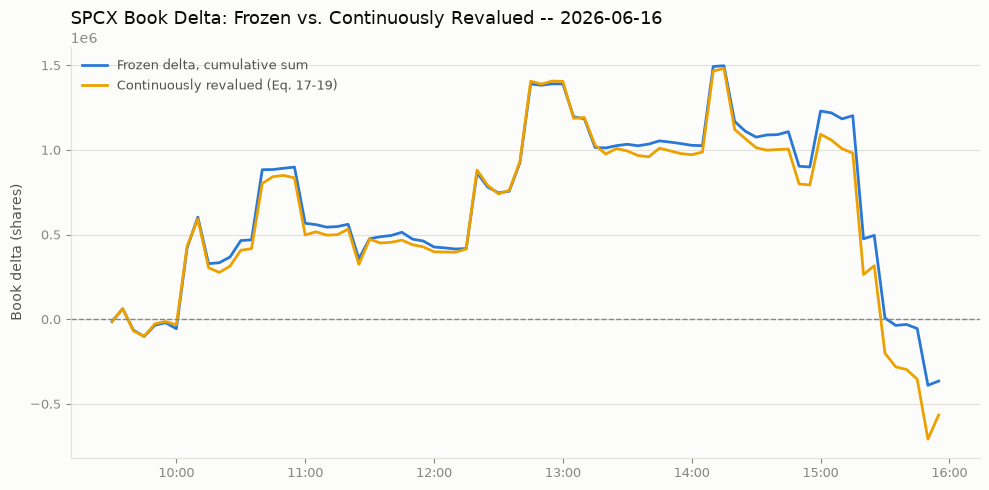

In [8]:
busiest_day = book_paths.groupby('trade_date')['n_option_trades'].sum().idxmax()
day_trades_ill = delta_arrivals.loc[delta_arrivals['trade_date'].eq(busiest_day)]
day_bars_ill = book_paths.loc[book_paths['trade_date'].eq(busiest_day)].sort_values('bar_time')

frozen_path = (day_trades_ill.groupby('bar_time')['signed_delta_shares'].sum()
               .reindex(day_bars_ill['bar_time'], fill_value=0.0).cumsum())

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)
ax.plot(day_bars_ill['bar_time'], frozen_path.to_numpy(), color=COLOR_ZERO_HEDGE,
        linewidth=2, label='Frozen delta, cumulative sum')
ax.plot(day_bars_ill['bar_time'], day_bars_ill['book_delta'], color=COLOR_STATIC_BAND,
        linewidth=2, label='Continuously revalued (Eq. 17-19)')
ax.axhline(0, color=INK_MUTED, linewidth=1, linestyle='--')
ax.set_title(f'SPCX Book Delta: Frozen vs. Continuously Revalued -- {busiest_day.date()}',
             color=INK_PRIMARY, fontsize=13, loc='left')
ax.set_ylabel('Book delta (shares)', color=INK_SECONDARY, fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.grid(axis='y', color=GRID_COLOR, linewidth=0.8)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
for side in ('left', 'bottom'):
    ax.spines[side].set_color(GRID_COLOR)
ax.tick_params(colors=INK_MUTED, labelsize=9)
legend = ax.legend(loc='best', frameon=False, fontsize=9)
for text in legend.get_texts():
    text.set_color(INK_SECONDARY)
fig.tight_layout()
fig.savefig(OUTPUT_FIGURE_DIR / 'spcx_revaluation_comparison.png', dpi=150,
            facecolor=fig.get_facecolor())
plt.show()

## 5. Calibrating the No-Trade Band `H` to This Book's Scale

As in notebook 04, `H` is selected empirically (Eq. 6 treats it as a backtested choice, not
a given). SPCX book delta lives in *shares*, and with this much option flow it reaches the
hundreds of thousands, so the grid is derived from the distribution of each day's maximum
absolute book delta: the 25/50/75/90th percentiles rounded to round-number bands.

count         22.0
mean      723320.0
std       717538.0
min        63640.0
25%       206129.0
50%       424693.0
75%       890153.0
max      2566076.0
dtype: float64
Percentiles (50/75/90/95/99): [ 424693.  890153. 1588268. 2243914. 2505537.]


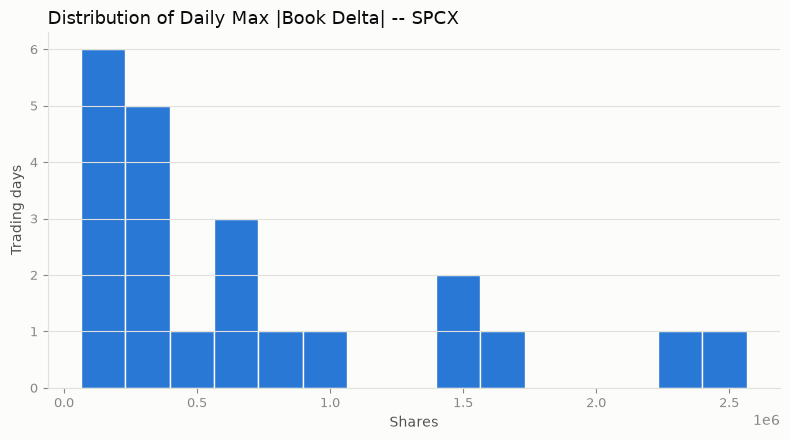


H grid (shares): ['200,000', '400,000', '900,000', '1,500,000']


In [9]:
daily_max_abs_delta = pd.Series({d: np.max(np.abs(p['book_delta'])) for d, p in day_paths.items()})
print(daily_max_abs_delta.describe().round(0))
print('Percentiles (50/75/90/95/99):',
      np.percentile(daily_max_abs_delta, [50, 75, 90, 95, 99]).round(0))

fig, ax = plt.subplots(figsize=(8, 4.5))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)
ax.hist(daily_max_abs_delta, bins=15, color=COLOR_ZERO_HEDGE, edgecolor=SURFACE)
ax.set_title('Distribution of Daily Max |Book Delta| -- SPCX', color=INK_PRIMARY,
             fontsize=13, loc='left')
ax.set_xlabel('Shares', color=INK_SECONDARY, fontsize=10)
ax.set_ylabel('Trading days', color=INK_SECONDARY, fontsize=10)
ax.grid(axis='y', color=GRID_COLOR, linewidth=0.8)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
for side in ('left', 'bottom'):
    ax.spines[side].set_color(GRID_COLOR)
ax.tick_params(colors=INK_MUTED, labelsize=9)
fig.tight_layout()
fig.savefig(OUTPUT_FIGURE_DIR / 'spcx_book_delta_scale.png', dpi=150,
            facecolor=fig.get_facecolor())
plt.show()


def nice_round(x: float) -> float:
    """Round to the nearest half step of the leading decade (e.g. 314159 -> 300000)."""
    m = 10 ** math.floor(math.log10(x))
    return float(np.round(x / m * 2) / 2 * m)


H_GRID = sorted({nice_round(p) for p in np.percentile(daily_max_abs_delta, [25, 50, 75, 90])})
EPS_GRID = [0.0, 0.05, 0.10]
COOLDOWN_GRID_MIN = [0, 15, 30]
HORIZON_GRID_MIN = [15, 30, 60]
METHOD_GRID = ['twap', 'vwap']
print(f'\nH grid (shares): {[f"{h:,.0f}" for h in H_GRID]}')

## 6. Trigger Rule, TWAP/VWAP Execution, and Execution Cost

Identical engine to notebook 04 (trigger with breach buffer `eps` and cooldown, override at
`2H`; TWAP/VWAP child schedules over horizon `tau`; spread + ADV-adjusted sqrt impact;
closing-auction treatment of the day's last bar), with the cost model **re-calibrated to
SPCX from the data itself**:

- **Half-spread** is measured, not proxied: the panel-wide median quoted half-spread of the
  underlying BBO.
- **Impact `alpha`** keeps notebook 04's anchoring rule -- a benchmark 100-share clip pays
  ~0.5 bps of notional beyond the half-spread at the panel's median 20-day ADV --
  `alpha = 0.5e-4 * sqrt(ADV_med / 100)`. Larger clips still bite through the sqrt term.
- **Closing auction**: any fill on the day's last bar crosses at the Nasdaq closing-cross
  price (zero spread) with `alpha` scaled by a factor derived exactly as in notebook 04 --
  sqrt depth scaling against the close's volume concentration measured in this panel,
  times the ~0.4 haircut for the temporary-impact share an auction cross does not pay.
- Hedge quantities are fractional shares, matching notebook 04's fractional-contract
  engine (sub-share rounding is immaterial at this book's scale).

In [10]:
SPCX_HALF_SPREAD = round(float(panel['spcx_half_spread'].median()), 3)   # $ per share
ADV_MED = float(pd.Series({d: p['spcx_adv_20d'][0] for d, p in day_paths.items()}).median())
IMPACT_ALPHA = round(0.5e-4 * math.sqrt(ADV_MED / 100.0), 4)
IMPACT_BETA = 0.5

bar_vol = book_paths.groupby('trade_date')['spcx_volume_5m']
last_bar_ratio = float((book_paths.groupby('trade_date')['spcx_volume_5m'].last()
                        / bar_vol.mean()).median())
CLOSE_IMPACT_FACTOR = min(1.0, round(0.4 / math.sqrt(max(last_bar_ratio, 1.0)), 2))

print(f'Half-spread (measured, median): ${SPCX_HALF_SPREAD:.3f}/share '
      f'({1e4 * SPCX_HALF_SPREAD / panel["spcx_price"].median():.1f} bps of the median price)')
print(f'Median 20-day ADV (proxy)     : {ADV_MED:,.0f} shares')
print(f'IMPACT_ALPHA (100-sh anchor)  : {IMPACT_ALPHA:.4f}  '
      f'(100-sh clip ~0.5 bps; 10k sh ~{1e4 * IMPACT_ALPHA * math.sqrt(10_000 / ADV_MED):.1f} bps)')
print(f'Last-bar volume concentration : {last_bar_ratio:.1f}x an average bar '
      f'-> CLOSE_IMPACT_FACTOR = {CLOSE_IMPACT_FACTOR:.2f}')


def child_order_cost(qty: float, price: float, adv: float, half_spread: float = SPCX_HALF_SPREAD,
                     alpha: float = IMPACT_ALPHA, beta: float = IMPACT_BETA,
                     at_close: bool = False):
    """(total, spread, impact) dollar cost of a stock child order of `qty` shares."""
    qty = abs(qty)
    if qty == 0.0:
        return 0.0, 0.0, 0.0
    if at_close:
        half_spread = 0.0
        alpha = alpha * CLOSE_IMPACT_FACTOR
    adv = max(adv, 1.0)
    spread_cost = qty * half_spread
    impact_cost = alpha * price * qty * ((qty / adv) ** beta)
    return spread_cost + impact_cost, spread_cost, impact_cost


def make_schedule(parent_qty, start_idx, n_bars, prices, volumes, horizon_min, method):
    n_child = max(int(round(horizon_min / BAR_MINUTES)), 1)
    idx = np.arange(start_idx, min(start_idx + n_child, n_bars))
    if len(idx) == 0:
        return idx, np.array([])
    if method == 'twap':
        weights = np.full(len(idx), 1.0 / len(idx))
    elif method == 'vwap':
        vol = np.clip(volumes[idx], 0, None)
        weights = vol / vol.sum() if vol.sum() > 0 else np.full(len(idx), 1.0 / len(idx))
    else:
        raise ValueError(f'Unknown execution method: {method}')
    return idx, parent_qty * weights


def simulate_day(day: dict, H, eps, cooldown_min, horizon_min, method,
                 full_hedge=False, zero_hedge=False, return_path=False, record_events=False):
    """One trading day, one strategy configuration (Backtest Procedure, steps 1-9)."""
    n = len(day['bar_time'])
    prices, adv, vol5, book = (day['spcx_price'], day['spcx_adv_20d'],
                               day['spcx_volume_5m'], day['book_delta'])

    hedge_cum = 0.0
    exec_cost = spread_cost = impact_cost = 0.0
    n_triggers = 0
    total_abs_hedge = 0.0
    sched_idx, sched_qty = np.array([], dtype=int), np.array([])
    cooldown_until = -1
    resid = np.zeros(n)
    events = []

    for j in range(n):
        if full_hedge:
            target_hedge = -book[j]
            incremental = target_hedge - hedge_cum
            if incremental != 0.0:
                c, s, im = child_order_cost(incremental, prices[j], adv[j], at_close=(j == n - 1))
                exec_cost += c; spread_cost += s; impact_cost += im
                total_abs_hedge += abs(incremental)
                n_triggers += 1
            hedge_cum = target_hedge
            resid[j] = 0.0
            continue
        if zero_hedge:
            resid[j] = book[j]
            continue

        due = sched_idx == j
        if due.any():
            q = float(sched_qty[due].sum())
            if q != 0.0:
                c, s, im = child_order_cost(q, prices[j], adv[j], at_close=(j == n - 1))
                exec_cost += c; spread_cost += s; impact_cost += im
                total_abs_hedge += abs(q)
                hedge_cum += q
                if record_events:
                    events.append(dict(bar_time=day['bar_time'][j], event_type='child_order',
                                       hedge_delta=q, book_delta_after=book[j] + hedge_cum,
                                       exec_cost=c, spread_cost=s, impact_cost=im))

        delta_now = book[j] + hedge_cum
        resid[j] = delta_now

        in_cooldown = j < cooldown_until
        breach = abs(delta_now) > H * (1 + eps)
        override = abs(delta_now) > 2 * H
        if breach and (not in_cooldown or override):
            n_triggers += 1
            parent = -delta_now
            sched_idx, sched_qty = make_schedule(parent, j + 1, n, prices, vol5, horizon_min, method)
            sched_end = sched_idx[-1] if len(sched_idx) else j
            cooldown_until = sched_end + 1 + int(round(cooldown_min / BAR_MINUTES))
            if record_events:
                events.append(dict(bar_time=day['bar_time'][j], event_type='trigger',
                                   hedge_delta=parent, book_delta_after=delta_now,
                                   exec_cost=0.0, spread_cost=0.0, impact_cost=0.0))

    close_qty = -resid[-1] if n > 0 else 0.0
    if not full_hedge and close_qty != 0.0:
        c, s, im = child_order_cost(close_qty, prices[-1], adv[-1], at_close=True)
        exec_cost += c; spread_cost += s; impact_cost += im
        total_abs_hedge += abs(close_qty)
        resid[-1] = 0.0
        if record_events:
            events.append(dict(bar_time=day['bar_time'][-1], event_type='close_flatten',
                               hedge_delta=close_qty, book_delta_after=0.0,
                               exec_cost=c, spread_cost=s, impact_cost=im))
    if full_hedge:
        close_qty = 0.0

    # Eq. 22 in equity units: residual shares x $ price move = dollar P&L per bar.
    price_diff = np.diff(prices)
    ell = resid[:-1] * price_diff
    result = dict(
        exec_cost=exec_cost, spread_cost=spread_cost, impact_cost=impact_cost,
        n_triggers=n_triggers, total_abs_hedge=total_abs_hedge,
        risk_sumsq=float(np.dot(ell, ell)), risk_count=len(ell),
        eod_delta_before_flatten=abs(close_qty),
    )
    if return_path:
        result['resid_path'] = resid
    if record_events:
        result['hedge_events'] = events
    return result

print('Engine defined: trigger rule + TWAP/VWAP execution + measured-spread cost model.')

Half-spread (measured, median): $0.027/share (1.7 bps of the median price)
Median 20-day ADV (proxy)     : 982,127 shares
IMPACT_ALPHA (100-sh anchor)  : 0.0050  (100-sh clip ~0.5 bps; 10k sh ~5.0 bps)
Last-bar volume concentration : 1.8x an average bar -> CLOSE_IMPACT_FACTOR = 0.30
Engine defined: trigger rule + TWAP/VWAP execution + measured-spread cost model.


## 7. Benchmarks: Zero Hedge and Full Hedge

Zero Hedge carries the revalued book all day and flattens once into the close (execution
cost lower bound, risk upper bound). Full Hedge re-flattens at every 5-minute bar (risk
exactly zero, cost upper bound). These anchor the Eq. 25-26 normalization.

In [11]:
def aggregate_over_days(day_paths: dict, record_events: bool = False, **sim_kwargs) -> dict:
    agg = dict(exec_cost=0.0, spread_cost=0.0, impact_cost=0.0, n_triggers=0,
               total_abs_hedge=0.0, risk_sumsq=0.0, risk_count=0)
    hedge_events = []
    for trade_date, day in day_paths.items():
        r = simulate_day(day, record_events=record_events, **sim_kwargs)
        for k in agg:
            agg[k] += r[k]
        if record_events:
            for event in r['hedge_events']:
                event['trade_date'] = trade_date
            hedge_events.extend(r['hedge_events'])
    agg['risk_rms'] = (agg['risk_sumsq'] / agg['risk_count']) ** 0.5 if agg['risk_count'] else 0.0
    if record_events:
        agg['hedge_events'] = hedge_events
    return agg


zero_hedge_agg = aggregate_over_days(day_paths, H=None, eps=None, cooldown_min=None,
                                     horizon_min=None, method=None, zero_hedge=True)
full_hedge_agg = aggregate_over_days(day_paths, H=None, eps=None, cooldown_min=None,
                                     horizon_min=None, method=None, full_hedge=True)

BENCHMARK_FIELDS = ['exec_cost', 'spread_cost', 'impact_cost', 'risk_rms', 'n_triggers', 'total_abs_hedge']
benchmark_table = pd.DataFrame([
    dict(strategy='zero_hedge', **{k: zero_hedge_agg[k] for k in BENCHMARK_FIELDS}),
    dict(strategy='full_hedge', **{k: full_hedge_agg[k] for k in BENCHMARK_FIELDS}),
]).rename(columns={'exec_cost': 'execution_cost', 'risk_rms': 'delta_risk_rms'})
benchmark_table.to_csv(BENCHMARKS_PATH, index=False)
print(f'Wrote benchmark aggregates to {BENCHMARKS_PATH.relative_to(PROJECT_ROOT)}')
benchmark_table

Wrote benchmark aggregates to outputs\tables\spcx_benchmark_results.csv


,strategy,execution_cost,spread_cost,impact_cost,delta_risk_rms,n_triggers,total_abs_hedge
0,zero_hedge,1.832972e+06,0.000000e+00,1.832972e+06,472775.882659,0,8.434275e+06
1,full_hedge,3.524846e+07,2.042543e+06,3.320592e+07,0.000000,1716,7.733020e+07


## 8. Grid Search Over theta = (H, eps, T_cooldown, e, tau)

Same grid shape as notebook 04 -- `H` from Section 5's empirical calibration, `eps` in
{0%, 5%, 10%}, cooldown in {0, 15, 30} min, `tau` in {15, 30, 60} min, TWAP/VWAP -- with
the full hedge-trade log of every configuration persisted in the notebook-04 format
(`band` holds `H`; `eps` and `cooldown_minutes` appended).

In [12]:
HEDGE_EVENT_COLUMNS = [
    'bar_time', 'event_type', 'band', 'method', 'horizon_minutes', 'hedge_delta',
    'book_delta_after', 'exec_cost', 'spread_cost', 'impact_cost', 'trade_date',
    'eps', 'cooldown_minutes',
]

t0 = time.time()
grid_rows = []
hedge_event_frames = []
for H, eps, cooldown_min, horizon_min, method in itertools.product(
        H_GRID, EPS_GRID, COOLDOWN_GRID_MIN, HORIZON_GRID_MIN, METHOD_GRID):
    agg = aggregate_over_days(day_paths, record_events=True, H=H, eps=eps,
                              cooldown_min=cooldown_min, horizon_min=horizon_min, method=method)
    grid_rows.append(dict(
        H=H, eps=eps, cooldown_min=cooldown_min, horizon_min=horizon_min, method=method,
        execution_cost=agg['exec_cost'], spread_cost=agg['spread_cost'],
        impact_cost=agg['impact_cost'], delta_risk_rms=agg['risk_rms'],
        n_triggers=agg['n_triggers'], total_abs_hedge=agg['total_abs_hedge'],
    ))
    if agg['hedge_events']:
        config_events = pd.DataFrame(agg['hedge_events'])
        config_events['band'] = H
        config_events['method'] = method
        config_events['horizon_minutes'] = horizon_min
        config_events['eps'] = eps
        config_events['cooldown_minutes'] = cooldown_min
        hedge_event_frames.append(config_events)

grid_df = pd.DataFrame(grid_rows)
print(f'Grid search over {len(grid_df)} configurations in {time.time() - t0:.1f}s')
grid_df.to_csv(GRID_RESULTS_PATH, index=False)

hedge_events = (pd.concat(hedge_event_frames, ignore_index=True) if hedge_event_frames
                else pd.DataFrame(columns=HEDGE_EVENT_COLUMNS))[HEDGE_EVENT_COLUMNS]
hedge_events.to_csv(HEDGE_EVENTS_PATH, index=False)
print(f'Wrote {len(hedge_events):,} hedge-trade events to {HEDGE_EVENTS_PATH.relative_to(PROJECT_ROOT)}')
print(f'Wrote grid results to {GRID_RESULTS_PATH.relative_to(PROJECT_ROOT)}')
grid_df.sort_values('execution_cost').head(10)

Grid search over 216 configurations in 1.3s


Wrote 61,353 hedge-trade events to data\processed\spcx_hedge_events.csv
Wrote grid results to outputs\tables\spcx_grid_results.csv


,H,eps,cooldown_min,horizon_min,method,execution_cost,spread_cost,impact_cost,delta_risk_rms,n_triggers,total_abs_hedge
214,1500000.0,0.1,30,60,twap,2.845778e+06,97166.246708,2.748611e+06,433507.916602,2,1.156494e+07
215,1500000.0,0.1,30,60,vwap,2.872902e+06,97166.246708,2.775735e+06,433392.298011,2,1.156494e+07
208,1500000.0,0.1,15,60,twap,3.821045e+06,126781.808549,3.694263e+06,426009.145983,3,1.282177e+07
209,1500000.0,0.1,15,60,vwap,3.837155e+06,126487.721106,3.710668e+06,425939.175864,3,1.282177e+07
179,1500000.0,0.0,30,60,vwap,3.914755e+06,162303.762112,3.752451e+06,398549.072123,4,1.376309e+07
167,1500000.0,0.0,0,60,vwap,3.914755e+06,162303.762112,3.752451e+06,398549.072123,4,1.376309e+07
173,1500000.0,0.0,15,60,vwap,3.914755e+06,162303.762112,3.752451e+06,398549.072123,4,1.376309e+07
172,1500000.0,0.0,15,60,twap,3.933437e+06,163547.832314,3.769889e+06,399048.283721,4,1.376309e+07
178,1500000.0,0.0,30,60,twap,3.933437e+06,163547.832314,3.769889e+06,399048.283721,4,1.376309e+07
166,1500000.0,0.0,0,60,twap,3.933437e+06,163547.832314,3.769889e+06,399048.283721,4,1.376309e+07


## 9. Standardized Objective and Optimal Configuration theta* (Eq. 24-28)

`C_exec_tilde = C_exec / C_exec(Full Hedge)`, `C_risk_tilde = C_risk / C_risk(Zero Hedge)`,
`L_std = C_exec_tilde + lambda_risk * C_risk_tilde`, base case `lambda_risk = 1.0`.

In [13]:
LAMBDA_RISK_BASE = 1.0

benchmarks = benchmark_table.set_index('strategy')
zero_hedge = benchmarks.loc['zero_hedge']
full_hedge = benchmarks.loc['full_hedge']

grid_df['cost_norm'] = grid_df['execution_cost'] / full_hedge['execution_cost']
grid_df['risk_norm'] = grid_df['delta_risk_rms'] / zero_hedge['delta_risk_rms']
grid_df['L_std'] = grid_df['cost_norm'] + LAMBDA_RISK_BASE * grid_df['risk_norm']

theta_star = grid_df.sort_values('L_std').iloc[0]
THETA_STAR_LABEL = (
    f"Static band theta* (H={theta_star['H']:,.0f} sh, eps={theta_star['eps']:.0%}, "
    f"cooldown={theta_star['cooldown_min']:.0f}m, {theta_star['method'].upper()}, "
    f"{theta_star['horizon_min']:.0f}m)"
)
print('theta* =', dict(H=theta_star['H'], eps=theta_star['eps'],
                       cooldown_min=theta_star['cooldown_min'],
                       horizon_min=theta_star['horizon_min'], method=theta_star['method']))

summary_table = pd.DataFrame([
    {'strategy': 'Zero Hedge', 'execution_cost': zero_hedge['execution_cost'],
     'delta_risk_rms': zero_hedge['delta_risk_rms'],
     'cost_norm': zero_hedge['execution_cost'] / full_hedge['execution_cost'], 'risk_norm': 1.0},
    {'strategy': 'Full Hedge', 'execution_cost': full_hedge['execution_cost'],
     'delta_risk_rms': full_hedge['delta_risk_rms'],
     'cost_norm': 1.0, 'risk_norm': full_hedge['delta_risk_rms'] / zero_hedge['delta_risk_rms']},
    {'strategy': THETA_STAR_LABEL, 'execution_cost': theta_star['execution_cost'],
     'delta_risk_rms': theta_star['delta_risk_rms'],
     'cost_norm': theta_star['cost_norm'], 'risk_norm': theta_star['risk_norm']},
])
summary_table['L_std'] = summary_table['cost_norm'] + LAMBDA_RISK_BASE * summary_table['risk_norm']
summary_table

theta* = {'H': np.float64(200000.0), 'eps': np.float64(0.0), 'cooldown_min': np.int64(30), 'horizon_min': np.int64(60), 'method': 'twap'}


,strategy,execution_cost,delta_risk_rms,cost_norm,risk_norm,L_std
0,Zero Hedge,1.832972e+06,472775.882659,0.052001,1.000000,1.052001
1,Full Hedge,3.524846e+07,0.000000,1.000000,0.000000,1.000000
2,"Static band theta* (H=200,000 sh, eps=0%, cool...",7.319450e+06,291288.152981,0.207653,0.616123,0.823776


## 10. Efficient Frontier: Execution Cost vs. Delta Risk (Standardized)

One point per configuration; `H` encoded as an ordinal single-hue ramp, method by marker
shape, benchmarks as stars, theta* as a diamond, Pareto frontier dashed.

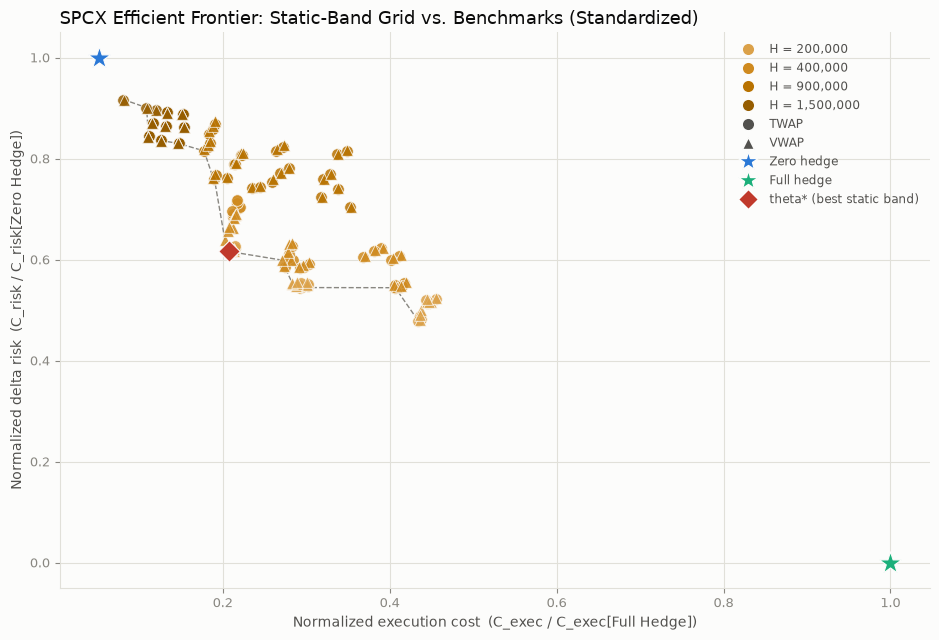

Wrote figure to outputs\figures\spcx_efficient_frontier_cost_vs_risk.png
Pareto-efficient configurations: 23 of 216


,H,eps,cooldown_min,horizon_min,method,cost_norm,risk_norm,L_std
0,1500000.0,0.10,30,60,twap,0.080735,0.916942,0.997676
1,1500000.0,0.10,30,60,vwap,0.081504,0.916697,0.998201
2,1500000.0,0.10,15,60,twap,0.108403,0.901081,1.009484
3,1500000.0,0.10,15,60,vwap,0.108860,0.900933,1.009793
4,1500000.0,0.00,0,60,vwap,0.111062,0.842998,0.954060
18,1500000.0,0.00,0,30,vwap,0.125980,0.835654,0.961634
36,1500000.0,0.00,0,15,vwap,0.146753,0.830224,0.976977
54,900000.0,0.05,0,60,twap,0.177706,0.815140,0.992846
64,900000.0,0.00,15,60,vwap,0.188745,0.760627,0.949373
65,900000.0,0.00,15,60,twap,0.189953,0.760488,0.950441


In [14]:
H_ORDER = sorted(grid_df['H'].unique())
H_COLORS = dict(zip(H_ORDER, BAND_RAMP))
METHOD_MARKERS = {'twap': 'o', 'vwap': '^'}


def pareto_frontier(df: pd.DataFrame, x_col: str, y_col: str) -> pd.DataFrame:
    ordered = df.sort_values([x_col, y_col]).reset_index(drop=True)
    keep, best_y = [], np.inf
    for i, row in ordered.iterrows():
        if row[y_col] < best_y:
            keep.append(i)
            best_y = row[y_col]
    return ordered.loc[keep]


frontier = pareto_frontier(grid_df, 'cost_norm', 'risk_norm')

fig, ax = plt.subplots(figsize=(9.5, 6.5))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

for H in H_ORDER:
    for method, marker in METHOD_MARKERS.items():
        subset = grid_df.loc[grid_df['H'].eq(H) & grid_df['method'].eq(method)]
        ax.scatter(subset['cost_norm'], subset['risk_norm'], color=H_COLORS[H], marker=marker,
                   s=70, alpha=0.85, edgecolor=SURFACE, linewidth=0.6, zorder=3)

ax.plot(frontier['cost_norm'], frontier['risk_norm'], color=INK_MUTED, linewidth=1,
        linestyle='--', zorder=2)
ax.scatter(summary_table.loc[0, 'cost_norm'], summary_table.loc[0, 'risk_norm'],
           color=COLOR_ZERO_HEDGE, marker='*', s=280, edgecolor=SURFACE, linewidth=0.8, zorder=4)
ax.scatter(summary_table.loc[1, 'cost_norm'], summary_table.loc[1, 'risk_norm'],
           color=COLOR_FULL_HEDGE, marker='*', s=280, edgecolor=SURFACE, linewidth=0.8, zorder=4)
ax.scatter(theta_star['cost_norm'], theta_star['risk_norm'], color=COLOR_THETA_STAR,
           marker='D', s=120, edgecolor=SURFACE, linewidth=0.8, zorder=5)

handles = (
    [plt.Line2D([0], [0], marker='o', linestyle='', markerfacecolor=H_COLORS[H],
                markeredgecolor=SURFACE, markersize=9, label=f'H = {H:,.0f}') for H in H_ORDER]
    + [plt.Line2D([0], [0], marker=marker, linestyle='', markerfacecolor=INK_SECONDARY,
                  markeredgecolor=SURFACE, markersize=9, label=method.upper())
       for method, marker in METHOD_MARKERS.items()]
    + [plt.Line2D([0], [0], marker='*', linestyle='', markerfacecolor=COLOR_ZERO_HEDGE,
                  markeredgecolor=SURFACE, markersize=15, label='Zero hedge'),
       plt.Line2D([0], [0], marker='*', linestyle='', markerfacecolor=COLOR_FULL_HEDGE,
                  markeredgecolor=SURFACE, markersize=15, label='Full hedge'),
       plt.Line2D([0], [0], marker='D', linestyle='', markerfacecolor=COLOR_THETA_STAR,
                  markeredgecolor=SURFACE, markersize=10, label='theta* (best static band)')]
)
legend = ax.legend(handles=handles, loc='upper right', frameon=False, fontsize=8.5)
for text in legend.get_texts():
    text.set_color(INK_SECONDARY)

ax.set_title('SPCX Efficient Frontier: Static-Band Grid vs. Benchmarks (Standardized)',
             color=INK_PRIMARY, fontsize=13, loc='left')
ax.set_xlabel('Normalized execution cost  (C_exec / C_exec[Full Hedge])',
              color=INK_SECONDARY, fontsize=10)
ax.set_ylabel('Normalized delta risk  (C_risk / C_risk[Zero Hedge])',
              color=INK_SECONDARY, fontsize=10)
ax.grid(color=GRID_COLOR, linewidth=0.8)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
for side in ('left', 'bottom'):
    ax.spines[side].set_color(GRID_COLOR)
ax.tick_params(colors=INK_MUTED, labelsize=9)
fig.tight_layout()
fig_path = OUTPUT_FIGURE_DIR / 'spcx_efficient_frontier_cost_vs_risk.png'
fig.savefig(fig_path, dpi=150, facecolor=fig.get_facecolor())
plt.show()

print(f'Wrote figure to {fig_path.relative_to(PROJECT_ROOT)}')
print(f'Pareto-efficient configurations: {len(frontier)} of {len(grid_df)}')
frontier[['H', 'eps', 'cooldown_min', 'horizon_min', 'method',
          'cost_norm', 'risk_norm', 'L_std']].head(10)

## 11. Benchmark Comparison vs. Zero Hedge and Full Hedge

,strategy,execution_cost,delta_risk_rms,cost_norm,risk_norm,L_std,cost_vs_zero_hedge_pct,cost_vs_full_hedge_pct,risk_vs_zero_hedge_pct
0,Zero Hedge,1.832972e+06,472775.882659,0.052001,1.000000,1.052001,0.000000,-94.799853,0.000000
1,Full Hedge,3.524846e+07,0.000000,1.000000,0.000000,1.000000,1823.022383,0.000000,-100.000000
2,"Static band theta* (H=200,000 sh, eps=0%, cool...",7.319450e+06,291288.152981,0.207653,0.616123,0.823776,299.321398,-79.234698,-38.387688


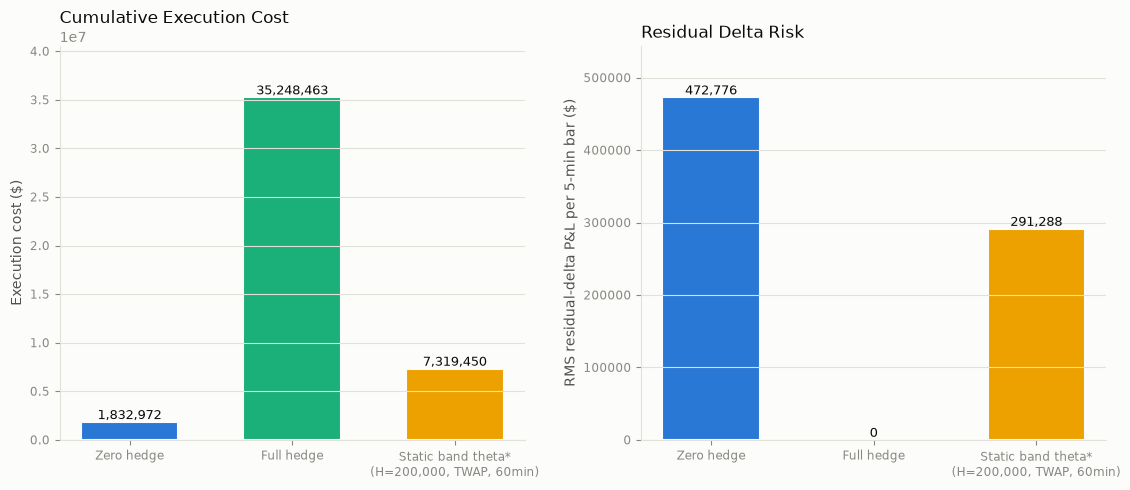

Wrote figure to outputs\figures\spcx_benchmark_comparison_cost_risk.png


In [15]:
benchmark_comparison = summary_table.copy()
benchmark_comparison['cost_vs_zero_hedge_pct'] = (benchmark_comparison['execution_cost']
                                                  / zero_hedge['execution_cost'] - 1) * 100
benchmark_comparison['cost_vs_full_hedge_pct'] = (benchmark_comparison['execution_cost']
                                                  / full_hedge['execution_cost'] - 1) * 100
benchmark_comparison['risk_vs_zero_hedge_pct'] = (benchmark_comparison['delta_risk_rms']
                                                  / zero_hedge['delta_risk_rms'] - 1) * 100
display(benchmark_comparison)

labels = ['Zero hedge', 'Full hedge',
          f"Static band theta*\n(H={theta_star['H']:,.0f}, {theta_star['method'].upper()}, "
          f"{theta_star['horizon_min']:.0f}min)"]
colors = [COLOR_ZERO_HEDGE, COLOR_FULL_HEDGE, COLOR_STATIC_BAND]
cost_values = [zero_hedge['execution_cost'], full_hedge['execution_cost'], theta_star['execution_cost']]
risk_values = [zero_hedge['delta_risk_rms'], full_hedge['delta_risk_rms'], theta_star['delta_risk_rms']]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5))
fig.patch.set_facecolor(SURFACE)
for ax, values, title, ylabel in (
    (axes[0], cost_values, 'Cumulative Execution Cost', 'Execution cost ($)'),
    (axes[1], risk_values, 'Residual Delta Risk', 'RMS residual-delta P&L per 5-min bar ($)'),
):
    ax.set_facecolor(SURFACE)
    bars_ = ax.bar(labels, values, color=colors, width=0.6, edgecolor=SURFACE, linewidth=1.5)
    for bar, value in zip(bars_, values):
        ax.text(bar.get_x() + bar.get_width() / 2, value, f'{value:,.0f}',
                ha='center', va='bottom', color=INK_PRIMARY, fontsize=9)
    ax.set_title(title, color=INK_PRIMARY, fontsize=12, loc='left')
    ax.set_ylabel(ylabel, color=INK_SECONDARY, fontsize=10)
    ax.set_ylim(top=max(values) * 1.15)
    ax.grid(axis='y', color=GRID_COLOR, linewidth=0.8)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color(GRID_COLOR)
    ax.tick_params(colors=INK_MUTED, labelsize=8.5)
fig.tight_layout()
fig_path = OUTPUT_FIGURE_DIR / 'spcx_benchmark_comparison_cost_risk.png'
fig.savefig(fig_path, dpi=150, facecolor=fig.get_facecolor())
plt.show()
print(f'Wrote figure to {fig_path.relative_to(PROJECT_ROOT)}')

## 12. Sensitivity Analysis

Same four sweeps as notebook 03: band width `H`; execution horizon and TWAP-vs-VWAP; the
spread and impact cost assumptions (both scale linearly in their parameter, so they are
rescaled analytically); and the risk-penalty weight `lambda_risk`.

In [16]:
band_sensitivity = (
    grid_df.groupby('H')
    .agg(execution_cost=('execution_cost', 'mean'), delta_risk_rms=('delta_risk_rms', 'mean'),
         L_std=('L_std', 'mean'), n_triggers=('n_triggers', 'mean'))
    .reset_index().sort_values('H')
)
band_sensitivity['avg_triggers_per_day'] = band_sensitivity['n_triggers'] / n_days
never_triggered = band_sensitivity.loc[band_sensitivity['n_triggers'].eq(0), 'H'].tolist()
if never_triggered:
    print(f'Bands never breached (identical to zero hedge): {never_triggered}')
band_sensitivity

,H,execution_cost,delta_risk_rms,L_std,n_triggers,avg_triggers_per_day
0,200000.0,1.114055e+07,264221.172676,0.874930,164.129630,7.460438
1,400000.0,1.056047e+07,295199.868202,0.923998,55.888889,2.540404
2,900000.0,8.799754e+06,373228.538873,1.039090,14.518519,0.659933
3,1500000.0,4.594494e+06,409352.939585,0.996196,3.629630,0.164983


In [17]:
binding_H = float(band_sensitivity.loc[band_sensitivity['n_triggers'].gt(0), 'H'].min())

horizon_sensitivity = (
    grid_df.loc[grid_df['H'].eq(binding_H)]
    .groupby('horizon_min')
    .agg(execution_cost=('execution_cost', 'mean'), delta_risk_rms=('delta_risk_rms', 'mean'),
         L_std=('L_std', 'mean'))
    .reset_index().sort_values('horizon_min')
)
print(f'Execution-horizon sensitivity (H={binding_H:,.0f}, the most binding band):')
display(horizon_sensitivity)

method_sensitivity = (
    grid_df.groupby('method')
    .agg(execution_cost=('execution_cost', 'mean'), delta_risk_rms=('delta_risk_rms', 'mean'),
         L_std=('L_std', 'mean'))
    .reset_index()
)
print('TWAP vs. VWAP (averaged over the rest of the grid):')
method_sensitivity

Execution-horizon sensitivity (H=200,000, the most binding band):


,horizon_min,execution_cost,delta_risk_rms,L_std
0,15,1.565180e+07,239759.612151,0.951174
1,30,1.034764e+07,259996.405557,0.843499
2,60,7.422216e+06,292907.500321,0.830117


TWAP vs. VWAP (averaged over the rest of the grid):


,method,execution_cost,delta_risk_rms,L_std
0,twap,8.785127e+06,335781.164974,0.959468
1,vwap,8.762509e+06,335220.094694,0.957639


In [18]:
SPREAD_MULTIPLIERS = [0.5, 1.0, 2.0, 4.0]
IMPACT_MULTIPLIERS = [0.5, 1.0, 2.0, 4.0]


def rescale_costs(df, spread_mult=1.0, impact_mult=1.0):
    out = df.copy()
    out['execution_cost'] = out['spread_cost'] * spread_mult + out['impact_cost'] * impact_mult
    return out


def best_row(rescaled, full_cost_scaled):
    r = rescaled.copy()
    r['cost_norm'] = r['execution_cost'] / full_cost_scaled
    return r.sort_values('cost_norm').iloc[0]


spread_rows = []
for mult in SPREAD_MULTIPLIERS:
    rescaled = rescale_costs(grid_df, spread_mult=mult)
    best = best_row(rescaled, full_hedge['spread_cost'] * mult + full_hedge['impact_cost'])
    spread_rows.append({'spread_multiplier': mult,
                        'implied_half_spread_dollars': SPCX_HALF_SPREAD * mult,
                        'best_H': best['H'], 'best_method': best['method'],
                        'best_execution_cost': best['execution_cost']})
spread_sensitivity = pd.DataFrame(spread_rows)

impact_rows = []
for mult in IMPACT_MULTIPLIERS:
    rescaled = rescale_costs(grid_df, impact_mult=mult)
    best = best_row(rescaled, full_hedge['spread_cost'] + full_hedge['impact_cost'] * mult)
    impact_rows.append({'impact_multiplier': mult, 'implied_alpha': IMPACT_ALPHA * mult,
                        'best_H': best['H'], 'best_method': best['method'],
                        'best_execution_cost': best['execution_cost']})
impact_sensitivity = pd.DataFrame(impact_rows)

print('Spread-assumption sensitivity (impact held at 1.0x):')
display(spread_sensitivity)
print('Impact-alpha sensitivity (spread held at 1.0x):')
impact_sensitivity

Spread-assumption sensitivity (impact held at 1.0x):


,spread_multiplier,implied_half_spread_dollars,best_H,best_method,best_execution_cost
0,0.5,0.0135,1500000.0,twap,2.797195e+06
1,1.0,0.0270,1500000.0,twap,2.845778e+06
2,2.0,0.0540,1500000.0,twap,2.942944e+06
3,4.0,0.1080,1500000.0,twap,3.137276e+06


Impact-alpha sensitivity (spread held at 1.0x):


,impact_multiplier,implied_alpha,best_H,best_method,best_execution_cost
0,0.5,0.0025,1500000.0,twap,1.471472e+06
1,1.0,0.0050,1500000.0,twap,2.845778e+06
2,2.0,0.0100,1500000.0,twap,5.594389e+06
3,4.0,0.0200,1500000.0,twap,1.109161e+07


In [19]:
LAMBDA_GRID = [0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0]

lambda_rows = []
for lam in LAMBDA_GRID:
    candidate = grid_df.copy()
    candidate['L_std'] = candidate['cost_norm'] + lam * candidate['risk_norm']
    winner = candidate.sort_values('L_std').iloc[0]
    full_hedge_L = 1.0 + lam * (full_hedge['delta_risk_rms'] / zero_hedge['delta_risk_rms'])
    lambda_rows.append(dict(lambda_risk=lam, best_H=winner['H'], best_eps=winner['eps'],
                            best_method=winner['method'], best_horizon_min=winner['horizon_min'],
                            static_band_L=winner['L_std'], full_hedge_L=full_hedge_L))
lambda_sensitivity = pd.DataFrame(lambda_rows)

crossover = lambda_sensitivity.loc[lambda_sensitivity['static_band_L'] > lambda_sensitivity['full_hedge_L']]
if len(crossover):
    print(f"Full Hedge overtakes the best static band once lambda_risk >= {crossover['lambda_risk'].iloc[0]:g}")
else:
    print(f'Full Hedge does not overtake the best static band up to lambda_risk={LAMBDA_GRID[-1]:g}.')
lambda_sensitivity

Full Hedge overtakes the best static band once lambda_risk >= 2


,lambda_risk,best_H,best_eps,best_method,best_horizon_min,static_band_L,full_hedge_L
0,0.10,1500000.0,0.10,twap,60,0.172429,1.0
1,0.25,1500000.0,0.10,twap,60,0.309970,1.0
2,0.50,200000.0,0.00,twap,60,0.515715,1.0
3,1.00,200000.0,0.00,twap,60,0.823776,1.0
4,2.00,200000.0,0.00,twap,30,1.381664,1.0
5,5.00,200000.0,0.05,twap,15,2.827559,1.0
6,10.00,200000.0,0.05,twap,15,5.220793,1.0


## 13. Intraday Walk-Through: Book Delta and Delta P&L by Strategy

Busiest day by option-trade count. Nothing is re-simulated: Zero Hedge is the revalued
book delta, Full Hedge is flat at zero, and the theta* residual is reconstructed as
`book_delta + cumulative hedge fills` from the persisted hedge log (asserted to end flat).

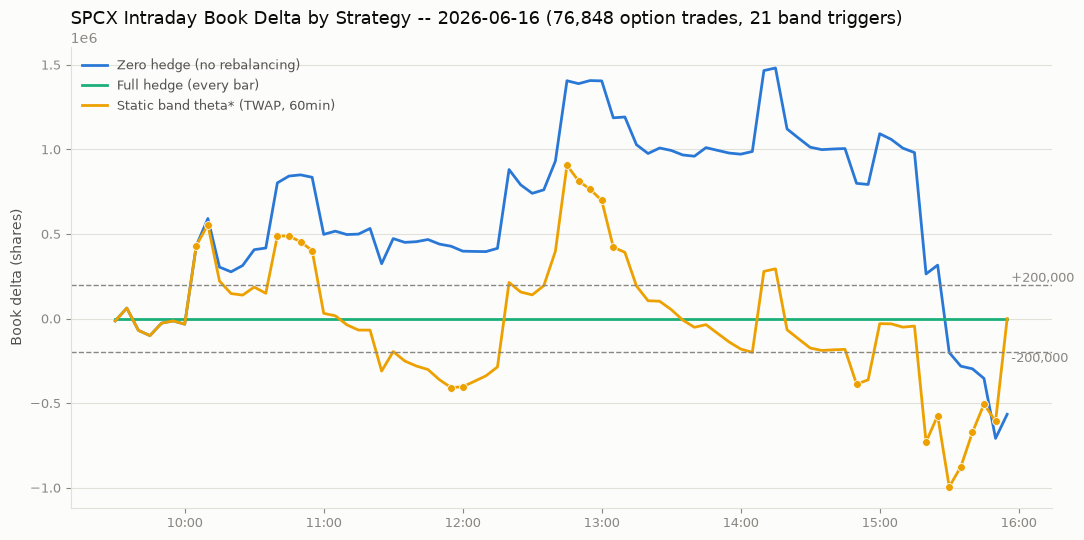

Wrote figure to outputs\figures\spcx_intraday_delta_path_by_strategy.png


In [20]:
def config_events(events: pd.DataFrame, theta: pd.Series) -> pd.DataFrame:
    mask = (events['band'].eq(theta['H'])
            & np.isclose(events['eps'], theta['eps'])
            & events['cooldown_minutes'].eq(theta['cooldown_min'])
            & events['horizon_minutes'].eq(theta['horizon_min'])
            & events['method'].eq(theta['method']))
    return events.loc[mask]


star_events = config_events(hedge_events, theta_star)

day_bars = book_paths.loc[book_paths['trade_date'].eq(busiest_day)].sort_values('bar_time').reset_index(drop=True)
day_events = star_events.loc[star_events['trade_date'].eq(busiest_day)]

fills_by_bar = (day_events.loc[day_events['event_type'].isin(['child_order', 'close_flatten'])]
                .groupby('bar_time')['hedge_delta'].sum()
                .reindex(day_bars['bar_time'], fill_value=0.0))
hedge_cum = fills_by_bar.cumsum().to_numpy()

zero_path = day_bars['book_delta'].to_numpy()
full_path = np.zeros(len(day_bars))
static_path = zero_path + hedge_cum
assert abs(static_path[-1]) < 1e-3, 'theta* close_flatten should leave the book flat'

triggers = day_events.loc[day_events['event_type'].eq('trigger')]
n_trades_sample = int(day_bars['n_option_trades'].sum())

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)
ax.plot(day_bars['bar_time'], zero_path, color=COLOR_ZERO_HEDGE, linewidth=2,
        label='Zero hedge (no rebalancing)')
ax.plot(day_bars['bar_time'], full_path, color=COLOR_FULL_HEDGE, linewidth=2,
        label='Full hedge (every bar)')
ax.plot(day_bars['bar_time'], static_path, color=COLOR_STATIC_BAND, linewidth=2,
        label=f"Static band theta* ({theta_star['method'].upper()}, {theta_star['horizon_min']:.0f}min)")
if not triggers.empty:
    ax.scatter(triggers['bar_time'], triggers['book_delta_after'], color=COLOR_STATIC_BAND,
               s=32, zorder=5, edgecolor=SURFACE, linewidth=0.6)

band_H = float(theta_star['H'])
ax.axhline(band_H, color=INK_MUTED, linestyle='--', linewidth=1)
ax.axhline(-band_H, color=INK_MUTED, linestyle='--', linewidth=1)
ax.text(day_bars['bar_time'].iloc[-1], band_H, f' +{band_H:,.0f}', color=INK_MUTED,
        fontsize=9, va='bottom')
ax.text(day_bars['bar_time'].iloc[-1], -band_H, f' -{band_H:,.0f}', color=INK_MUTED,
        fontsize=9, va='top')

ax.set_title(f'SPCX Intraday Book Delta by Strategy -- {busiest_day.date()} '
             f'({n_trades_sample:,} option trades, {len(triggers)} band triggers)',
             color=INK_PRIMARY, fontsize=13, loc='left')
ax.set_ylabel('Book delta (shares)', color=INK_SECONDARY, fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.grid(axis='y', color=GRID_COLOR, linewidth=0.8)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
for side in ('left', 'bottom'):
    ax.spines[side].set_color(GRID_COLOR)
ax.tick_params(colors=INK_MUTED, labelsize=9)
legend = ax.legend(loc='upper left', frameon=False, fontsize=9)
for text in legend.get_texts():
    text.set_color(INK_SECONDARY)
fig.tight_layout()
fig_path = OUTPUT_FIGURE_DIR / 'spcx_intraday_delta_path_by_strategy.png'
fig.savefig(fig_path, dpi=150, facecolor=fig.get_facecolor())
plt.show()
print(f'Wrote figure to {fig_path.relative_to(PROJECT_ROOT)}')

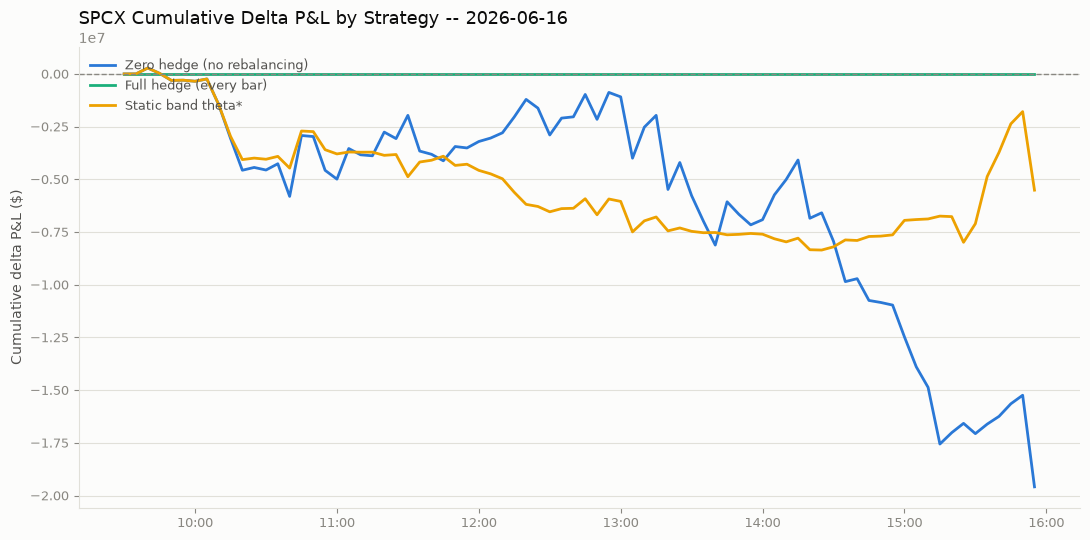

Wrote figure to outputs\figures\spcx_intraday_delta_pnl_by_strategy.png
End-of-day delta P&L -- zero hedge: -19,585,699, full hedge: 0, static band theta*: -5,513,756


In [21]:
def compute_delta_pnl(resid: np.ndarray, price: np.ndarray) -> np.ndarray:
    """Cumulative mark-to-market P&L ($) of carrying resid[t-1] SHARES through the price
    move to t -- shares x $ move, no multiplier (equity units)."""
    price_diff = np.diff(price, prepend=price[0])
    resid_prev = np.concatenate([[0.0], resid[:-1]])
    return np.cumsum(resid_prev * price_diff)


price_sample = day_bars['spcx_price'].to_numpy()
zero_pnl = compute_delta_pnl(zero_path, price_sample)
full_pnl = compute_delta_pnl(full_path, price_sample)
static_pnl = compute_delta_pnl(static_path, price_sample)

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)
ax.plot(day_bars['bar_time'], zero_pnl, color=COLOR_ZERO_HEDGE, linewidth=2,
        label='Zero hedge (no rebalancing)')
ax.plot(day_bars['bar_time'], full_pnl, color=COLOR_FULL_HEDGE, linewidth=2,
        label='Full hedge (every bar)')
ax.plot(day_bars['bar_time'], static_pnl, color=COLOR_STATIC_BAND, linewidth=2,
        label='Static band theta*')
ax.axhline(0, color=INK_MUTED, linestyle='--', linewidth=1)
ax.set_title(f'SPCX Cumulative Delta P&L by Strategy -- {busiest_day.date()}',
             color=INK_PRIMARY, fontsize=13, loc='left')
ax.set_ylabel('Cumulative delta P&L ($)', color=INK_SECONDARY, fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.grid(axis='y', color=GRID_COLOR, linewidth=0.8)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
for side in ('left', 'bottom'):
    ax.spines[side].set_color(GRID_COLOR)
ax.tick_params(colors=INK_MUTED, labelsize=9)
legend = ax.legend(loc='upper left', frameon=False, fontsize=9)
for text in legend.get_texts():
    text.set_color(INK_SECONDARY)
fig.tight_layout()
fig_path = OUTPUT_FIGURE_DIR / 'spcx_intraday_delta_pnl_by_strategy.png'
fig.savefig(fig_path, dpi=150, facecolor=fig.get_facecolor())
plt.show()
print(f'Wrote figure to {fig_path.relative_to(PROJECT_ROOT)}')
print(f'End-of-day delta P&L -- zero hedge: {zero_pnl[-1]:,.0f}, full hedge: {full_pnl[-1]:,.0f}, '
      f'static band theta*: {static_pnl[-1]:,.0f}')

## 14. theta* Unified Trade Blotter: Option Trades, Stock Hedges, and Portfolio Delta

Same construction as notebook 03 Section 12, in equity units: **`option_trade`** rows are
every simulated option print with its arrival delta in shares; **`trigger` / `child_order`
/ `close_flatten`** rows are theta*'s stock-hedge events (`instrument = SPCX`, quantities
in shares); **`bar_mark`** rows carry the bar-close portfolio state and the per-bar
`delta_pnl` (shares x price move). Option prints carry their bar's closing portfolio state
(per-trade attribution does not reconcile under continuous revaluation). Both CSVs open
with a `#` comment stamping the theta* configuration -- read them back with
`pd.read_csv(..., comment='#')`.

In [22]:
option_trades = delta_arrivals[['trade_id', 'timestamp_et', 'bar_time', 'trade_date',
                                'symbol', 'side', 'quantity', 'exec_price', 'delta',
                                'signed_delta_shares']]
assert len(option_trades) == book_paths['n_option_trades'].sum()

star_fills = star_events.loc[star_events['event_type'].isin(['child_order', 'close_flatten'])]
fills_per_bar = star_fills.groupby('bar_time')['hedge_delta'].sum()

portfolio_by_bar = (book_paths[['trade_date', 'bar_time', 'spcx_price', 'book_delta']]
                    .sort_values('bar_time').reset_index(drop=True))
portfolio_by_bar['stock_hedge_position'] = (
    portfolio_by_bar['bar_time'].map(fills_per_bar).fillna(0.0)
    .groupby(portfolio_by_bar['trade_date']).cumsum()
)
portfolio_by_bar['portfolio_delta'] = (portfolio_by_bar['book_delta']
                                       + portfolio_by_bar['stock_hedge_position'])
assert portfolio_by_bar.groupby('trade_date')['portfolio_delta'].last().abs().max() < 1e-3, \
    'theta* close_flatten should leave every day flat'

portfolio_by_bar['delta_pnl'] = (
    portfolio_by_bar.groupby('trade_date')['portfolio_delta'].shift()
    * portfolio_by_bar.groupby('trade_date')['spcx_price'].diff()
).fillna(0.0)
busiest_day_pnl = portfolio_by_bar.loc[portfolio_by_bar['trade_date'].eq(busiest_day), 'delta_pnl'].sum()
assert abs(busiest_day_pnl - static_pnl[-1]) < 0.01, \
    'per-bar delta_pnl must reconcile with the Section 13 walk-through'

THETA_STAR_HEADER = (
    f"# theta* configuration (SPCX): H={theta_star['H']:,.0f} shares, eps={theta_star['eps']:.0%}, "
    f"T_cooldown={theta_star['cooldown_min']:.0f} min, method={theta_star['method'].upper()}, "
    f"tau={theta_star['horizon_min']:.0f} min -- selected by minimizing L_std at "
    f"lambda={LAMBDA_RISK_BASE:g} (Eq. 24-28); engine cost model: alpha={IMPACT_ALPHA:g}, "
    f"beta={IMPACT_BETA:g}, half-spread=${SPCX_HALF_SPREAD:g}/share, "
    f"closing-cross impact factor {CLOSE_IMPACT_FACTOR:g}"
)


def to_csv_with_config_header(df: pd.DataFrame, path: Path) -> None:
    with open(path, 'w', newline='', encoding='utf-8') as f:
        f.write(THETA_STAR_HEADER + '\n')
        df.to_csv(f, index=False)


path_by_bar = OUTPUT_TABLE_DIR / 'spcx_theta_star_portfolio_delta_by_bar.csv'
to_csv_with_config_header(portfolio_by_bar, path_by_bar)

bar_state = portfolio_by_bar.set_index('bar_time')

option_rows = pd.DataFrame({
    'trade_date': option_trades['trade_date'],
    'timestamp': option_trades['timestamp_et'],
    'bar_time': option_trades['bar_time'],
    'event_type': 'option_trade',
    'instrument': option_trades['symbol'],
    'side': option_trades['side'],
    'quantity': option_trades['quantity'].astype(float),
    'price': option_trades['exec_price'],
    'option_delta': option_trades['delta'],
    'delta_traded': option_trades['signed_delta_shares'],
    'exec_cost': np.nan, 'spread_cost': np.nan, 'impact_cost': np.nan,
    'book_delta': option_trades['bar_time'].map(bar_state['book_delta']),
    'stock_hedge_position': option_trades['bar_time'].map(bar_state['stock_hedge_position']),
    'portfolio_delta': option_trades['bar_time'].map(bar_state['portfolio_delta']),
    'delta_pnl': np.nan,
})

se = star_events.reset_index(drop=True)
se_is_trigger = se['event_type'].eq('trigger')
se_book_delta = se['bar_time'].map(bar_state['book_delta'])
stock_rows = pd.DataFrame({
    'trade_date': se['trade_date'],
    'timestamp': se['bar_time'],
    'bar_time': se['bar_time'],
    'event_type': se['event_type'],
    'instrument': 'SPCX',
    'side': np.where(se['hedge_delta'] >= 0, 'BUY', 'SELL'),
    'quantity': se['hedge_delta'].abs(),
    'price': np.where(se_is_trigger, np.nan, se['bar_time'].map(bar_state['spcx_price'])),
    'option_delta': np.nan,
    'delta_traded': np.where(se_is_trigger, 0.0, se['hedge_delta']),
    'exec_cost': se['exec_cost'], 'spread_cost': se['spread_cost'], 'impact_cost': se['impact_cost'],
    'book_delta': se_book_delta,
    'stock_hedge_position': se['book_delta_after'] - se_book_delta,
    'portfolio_delta': se['book_delta_after'],
    'delta_pnl': np.nan,
})

bar_rows = pd.DataFrame({
    'trade_date': portfolio_by_bar['trade_date'],
    'timestamp': portfolio_by_bar['bar_time'] + pd.Timedelta(minutes=BAR_MINUTES),
    'bar_time': portfolio_by_bar['bar_time'],
    'event_type': 'bar_mark',
    'instrument': np.nan, 'side': np.nan, 'quantity': np.nan,
    'price': portfolio_by_bar['spcx_price'],
    'option_delta': np.nan, 'delta_traded': np.nan,
    'exec_cost': np.nan, 'spread_cost': np.nan, 'impact_cost': np.nan,
    'book_delta': portfolio_by_bar['book_delta'],
    'stock_hedge_position': portfolio_by_bar['stock_hedge_position'],
    'portfolio_delta': portfolio_by_bar['portfolio_delta'],
    'delta_pnl': portfolio_by_bar['delta_pnl'],
})

EVENT_ORDER = {'child_order': 0, 'trigger': 1, 'close_flatten': 2, 'option_trade': 3, 'bar_mark': 4}
blotter = pd.concat([option_rows, stock_rows, bar_rows], ignore_index=True)
blotter['event_rank'] = blotter['event_type'].map(EVENT_ORDER)
blotter = (blotter.sort_values(['bar_time', 'timestamp', 'event_rank'], kind='stable')
           .drop(columns='event_rank').reset_index(drop=True))

blotter_path = OUTPUT_TABLE_DIR / 'spcx_theta_star_trade_blotter.csv'
to_csv_with_config_header(blotter, blotter_path)

n_triggers_star = int(se_is_trigger.sum())
print(THETA_STAR_HEADER)
print(f'theta* unified trade blotter over {n_days} trading days: {len(blotter):,} rows')
print(f"  option trades:     {len(option_trades):,} prints ({len(option_trades) / n_days:,.0f}/day), "
      f"{option_trades['quantity'].sum():,.0f} option contracts, "
      f"{option_trades['signed_delta_shares'].abs().sum():,.0f} shares of delta traded")
print(f"  band triggers:     {n_triggers_star:,} total ({n_triggers_star / n_days:.1f}/day)")
print(f"  stock hedge fills: {len(star_fills):,} total ({len(star_fills) / n_days:.1f}/day), "
      f"{star_fills['hedge_delta'].abs().sum():,.0f} shares traded")
print(f"  execution cost:    ${star_fills['exec_cost'].sum():,.0f} "
      f"(spread ${star_fills['spread_cost'].sum():,.0f} + impact ${star_fills['impact_cost'].sum():,.0f})")
print(f"  bar marks:         {len(bar_rows):,} rows (delta P&L sums to "
      f"${bar_rows['delta_pnl'].sum():,.0f} across the period)")
print(f'Wrote the full theta* blotter to {blotter_path.relative_to(PROJECT_ROOT)}')
print(f'Wrote the per-bar portfolio-delta path to {path_by_bar.relative_to(PROJECT_ROOT)}')
print()

PREVIEW_COLS = ['timestamp', 'event_type', 'instrument', 'side', 'quantity', 'price',
                'delta_traded', 'stock_hedge_position', 'portfolio_delta', 'delta_pnl']
day_blotter = blotter.loc[blotter['trade_date'].eq(busiest_day)].reset_index(drop=True)
stock_positions = day_blotter.index[day_blotter['instrument'].eq('SPCX')]
preview_start = max(int(stock_positions[0]) - 5, 0) if len(stock_positions) else 0
print(f'Sample-day blotter ({busiest_day.date()}), around the first band trigger:')
day_blotter.iloc[preview_start:preview_start + 30][PREVIEW_COLS]

# theta* configuration (SPCX): H=200,000 shares, eps=0%, T_cooldown=30 min, method=TWAP, tau=60 min -- selected by minimizing L_std at lambda=1 (Eq. 24-28); engine cost model: alpha=0.005, beta=0.5, half-spread=$0.027/share, closing-cross impact factor 0.3
theta* unified trade blotter over 22 trading days: 365,447 rows
  option trades:     362,847 prints (16,493/day), 5,910,724 option contracts, 146,097,784 shares of delta traded
  band triggers:     225 total (10.2/day)
  stock hedge fills: 659 total (30.0/day), 32,266,775 shares traded
  execution cost:    $7,319,450 (spread $747,022 + impact $6,572,427)
  bar marks:         1,716 rows (delta P&L sums to $20,852,464 across the period)
Wrote the full theta* blotter to outputs\tables\spcx_theta_star_trade_blotter.csv
Wrote the per-bar portfolio-delta path to outputs\tables\spcx_theta_star_portfolio_delta_by_bar.csv

Sample-day blotter (2026-06-16), around the first band trigger:


,timestamp,event_type,instrument,side,quantity,price,delta_traded,stock_hedge_position,portfolio_delta,delta_pnl
14723,2026-06-16 10:04:59,option_trade,SPCX 260821P00180000,BUY,1.000000,24.806489,-24.897073,0.0,-32790.230143,NaN
14724,2026-06-16 10:04:59,option_trade,SPCX 260918P00150000,SELL,1.000000,14.865782,17.057177,0.0,-32790.230143,NaN
14725,2026-06-16 10:04:59,option_trade,SPCX 260717P00200000,BUY,2.000000,23.618829,-62.729033,0.0,-32790.230143,NaN
14726,2026-06-16 10:04:59,option_trade,SPCX 260618C00210000,BUY,1.000000,13.602391,75.207197,0.0,-32790.230143,NaN
14727,2026-06-16 10:05:00,bar_mark,NaN,NaN,NaN,222.800000,NaN,0.0,-32790.230143,-50593.245216
14728,2026-06-16 10:05:00,trigger,SPCX,SELL,431222.288283,NaN,0.000000,0.0,431222.288283,NaN
14729,2026-06-16 10:05:00,option_trade,SPCX 260618C00230000,SELL,3.000000,7.240651,-97.770326,0.0,431222.288283,NaN
14730,2026-06-16 10:05:00,option_trade,SPCX 260618P00150000,BUY,1.000000,0.206455,-0.001933,0.0,431222.288283,NaN
14731,2026-06-16 10:05:00,option_trade,SPCX 260618C00220000,BUY,2.000000,10.638833,101.885781,0.0,431222.288283,NaN
14732,2026-06-16 10:05:00,option_trade,SPCX 260618C00210000,BUY,11.000000,13.602391,768.556472,0.0,431222.288283,NaN


## 15. Final Recommendation

In [23]:
cost_saving_vs_full = (1 - theta_star['cost_norm']) * 100
risk_saving_vs_zero = (1 - theta_star['risk_norm']) * 100
cost_vs_zero = (theta_star['execution_cost'] / zero_hedge['execution_cost'] - 1) * 100
cost_saved_total = full_hedge['execution_cost'] - theta_star['execution_cost']

print('SPCX theta* = ' f"(H={theta_star['H']:,.0f} shares, eps={theta_star['eps']:.0%}, "
      f"T_cooldown={theta_star['cooldown_min']:.0f}min, e={theta_star['method'].upper()}, "
      f"tau={theta_star['horizon_min']:.0f}min)")
print(f'Execution cost: {cost_saving_vs_full:.1f}% lower than Full Hedge; '
      f'{cost_vs_zero:+.1f}% vs. Zero Hedge.')
print(f'Delta risk (RMS realized residual-delta P&L): {risk_saving_vs_zero:.1f}% lower than Zero Hedge.')
print(f"Standardized loss L_std(theta*) = {theta_star['L_std']:.3f} vs. Zero Hedge "
      f"{summary_table.loc[0, 'L_std']:.3f} and Full Hedge {summary_table.loc[1, 'L_std']:.3f}.")
print()
print(f"Execution cost, Full Hedge:         ${full_hedge['execution_cost']:,.0f} over {n_days} trading days")
print(f"Execution cost, static band theta*: ${theta_star['execution_cost']:,.0f}")
print(f'Saving vs. Full Hedge:              ${cost_saved_total:,.0f} total '
      f'(~${cost_saved_total / n_days:,.0f} per trading day)')
print()
print('Delta risk accepted in exchange (RMS residual-delta P&L per 5-minute bar):')
print(f"  Full Hedge: $0 by construction | theta*: ${theta_star['delta_risk_rms']:,.0f} | "
      f"Zero Hedge: ${zero_hedge['delta_risk_rms']:,.0f}")
print()
print('The static-band framework transfers from ES futures options to a single-name equity')
print('option book: bands + buffer + cooldown + TWAP/VWAP execution reduce the standardized')
print('cost-risk loss relative to both benchmarks on the SPCX backtest as well.')
print()
print('Caveats specific to SPCX: the share-volume/ADV proxy comes from 1-second BBO sampling')
print('(undercounts true volume), the synthetic tape trades far more delta than the stock')
print("prints, and bvol_1m is the tape's own ATM implied vol -- so dollar cost levels lean on")
print('the cost-model assumptions even more than in ES. The normalized comparisons and the')
print('Section 12 sweeps are the robust quantities.')

SPCX theta* = (H=200,000 shares, eps=0%, T_cooldown=30min, e=TWAP, tau=60min)
Execution cost: 79.2% lower than Full Hedge; +299.3% vs. Zero Hedge.
Delta risk (RMS realized residual-delta P&L): 38.4% lower than Zero Hedge.
Standardized loss L_std(theta*) = 0.824 vs. Zero Hedge 1.052 and Full Hedge 1.000.

Execution cost, Full Hedge:         $35,248,463 over 22 trading days
Execution cost, static band theta*: $7,319,450
Saving vs. Full Hedge:              $27,929,013 total (~$1,269,501 per trading day)

Delta risk accepted in exchange (RMS residual-delta P&L per 5-minute bar):
  Full Hedge: $0 by construction | theta*: $291,288 | Zero Hedge: $472,776

The static-band framework transfers from ES futures options to a single-name equity
option book: bands + buffer + cooldown + TWAP/VWAP execution reduce the standardized
cost-risk loss relative to both benchmarks on the SPCX backtest as well.

Caveats specific to SPCX: the share-volume/ADV proxy comes from 1-second BBO sampling
(undercounts 